In [1079]:
# Imports 

import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, norm
from scipy.stats import ttest_ind
from matplotlib import pyplot as plt
import time
import math
from collections import defaultdict
from brokenaxes import brokenaxes
from scipy.stats import mannwhitneyu
from itertools import combinations

from wcwidth import width

In [1080]:
# Directories and Global Variables
DATA_DIRECTORY = "./results"

# Retreive all Directories and files in the results 
QUALITY_DIRECTORIES = os.listdir(DATA_DIRECTORY)

In [1081]:
files = []
for q in QUALITY_DIRECTORIES: 
    runs = os.listdir(f"{DATA_DIRECTORY}/{q}")
    for f in runs: 
        files.append(f"{q}/{f}")
files

['all-off/run_06.csv',
 'all-off/run_14.csv',
 'all-off/run_29.csv',
 'all-off/run_03.csv',
 'all-off/run_02.csv',
 'all-off/run_70.csv',
 'all-off/run_102.csv',
 'all-off/run_114.csv',
 'all-off/run_72.csv',
 'all-off/run_99.csv',
 'all-off/run_98.csv',
 'all-off/run_101.csv',
 'all-off/run_115.csv',
 'all-off/run_105.csv',
 'all-off/run_88.csv',
 'all-off/run_62.csv',
 'all-off/run_112.csv',
 'all-off/run_107.csv',
 'all-off/run_50.csv',
 'all-off/run_92.csv',
 'all-off/run_79.csv',
 'all-off/run_84.csv',
 'all-off/run_90.csv',
 'all-off/run_46.csv',
 'all-off/run_120.csv',
 'all-off/run_81.csv',
 'all-off/run_94.csv',
 'all-off/run_83.csv',
 'all-off/run_24.csv',
 'all-off/run_09.csv',
 'ambient-mode/run_13.csv',
 'ambient-mode/run_11.csv',
 'ambient-mode/run_38.csv',
 'ambient-mode/run_15.csv',
 'ambient-mode/run_16.csv',
 'ambient-mode/run_117.csv',
 'ambient-mode/run_71.csv',
 'ambient-mode/run_65.csv',
 'ambient-mode/run_58.csv',
 'ambient-mode/run_64.csv',
 'ambient-mode/run_73

In [1082]:
example = pd.read_csv(f"{DATA_DIRECTORY}/{files[0]}")[['Time', 'SYSTEM_POWER (Watts)']]
first_time = example['Time'].iloc[0]
example['Time'] = example['Time'].apply(lambda x: (x - first_time) / 1000)
example.head(10)

,Time,SYSTEM_POWER (Watts)
0,0.000,8.640646
1,0.000,8.640646
2,0.206,2.221175
3,0.408,2.221175
4,0.610,2.221175
5,0.820,2.221175
6,1.023,2.595312
7,1.233,2.595312
8,1.442,2.595312
9,1.650,2.595312


In [1083]:
# Check whether Data is normal

stats, p_val = shapiro(example['SYSTEM_POWER (Watts)'])

print(f"With p-val {p_val}, the data is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}")

With p-val 1.1864235031538216e-29, the data is NOT NORMAL


In [1084]:
# Normalising the data

mean = example['SYSTEM_POWER (Watts)'].mean()
std = example['SYSTEM_POWER (Watts)'].std()
outlier = []
max_diff = 0
print(f"std: {3 * std}")
for idx, val in enumerate(example['SYSTEM_POWER (Watts)']): 
    diff = mean - val
    if np.abs(diff) > max_diff: max_diff = np.abs(diff) 
    if np.abs(diff) > 3*std: 
        print(f"Found outlier at {idx}")
        outlier.append(idx)

print(max_diff)
normalised_example = example.drop(index=outlier) 
normalised_example   


std: 1.7711237292219826
Found outlier at 0
Found outlier at 1
6.254865449993577


,Time,SYSTEM_POWER (Watts)
2,0.206,2.221175
3,0.408,2.221175
4,0.610,2.221175
5,0.820,2.221175
6,1.023,2.595312
...,...,...
287,59.274,2.414130
288,59.483,2.414130
289,59.693,2.414130
290,59.902,2.414130


Text(0, 0.5, 'System Power measurement (Watts)')

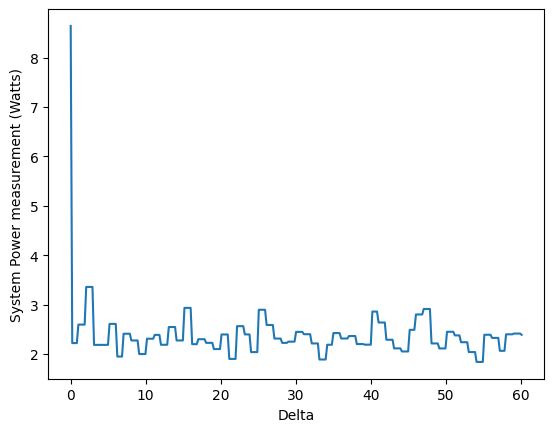

In [1085]:
#Plotting data distribution
plt.plot(example['Time'], example['SYSTEM_POWER (Watts)'])
plt.xlabel("Delta")
plt.ylabel("System Power measurement (Watts)")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x1124f6850>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x1124f6990>,
 'cmins': <matplotlib.collections.LineCollection at 0x1124f6ad0>,
 'cbars': <matplotlib.collections.LineCollection at 0x1124f6c10>}

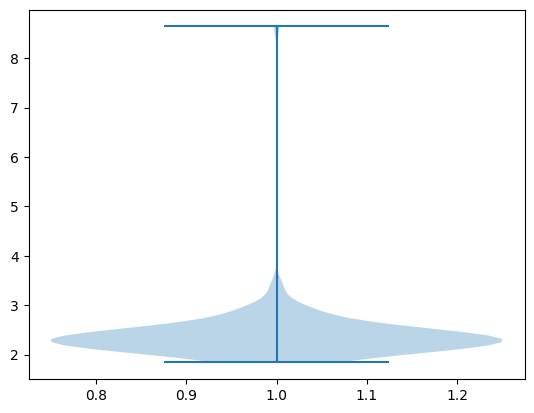

In [1086]:
# Violin plots

plt.violinplot(example['SYSTEM_POWER (Watts)'])


### Creating a general setup to create combinations by subcategories 

The outlier removal didn't work, possibly becasue there are not enough sample. Might have to do something else. 

In [1087]:
dataframes = {}
for f in files: 
    print(f"======== Converting file '{f}' ========")
    df = pd.read_csv(f"{DATA_DIRECTORY}/{f}")[['Time', 'SYSTEM_POWER (Watts)']]
    first_time = df['Time'].iloc[0]
    df['Time'] = df['Time'].apply(lambda x: (x - first_time) / 1000)
    dataframes[f] = df
    
dataframes[f]

======== Converting file 'all-off/run_06.csv' ========
======== Converting file 'all-off/run_14.csv' ========
======== Converting file 'all-off/run_29.csv' ========
======== Converting file 'all-off/run_03.csv' ========
======== Converting file 'all-off/run_02.csv' ========
======== Converting file 'all-off/run_70.csv' ========
======== Converting file 'all-off/run_102.csv' ========
======== Converting file 'all-off/run_114.csv' ========
======== Converting file 'all-off/run_72.csv' ========
======== Converting file 'all-off/run_99.csv' ========
======== Converting file 'all-off/run_98.csv' ========
======== Converting file 'all-off/run_101.csv' ========
======== Converting file 'all-off/run_115.csv' ========
======== Converting file 'all-off/run_105.csv' ========
======== Converting file 'all-off/run_88.csv' ========
======== Converting file 'all-off/run_62.csv' ========
======== Converting file 'all-off/run_112.csv' ========
======== Converting file 'all-off/run_107.csv' ========
===

,Time,SYSTEM_POWER (Watts)
0,0.000,2.244406
1,0.001,2.244406
2,0.211,2.244406
3,0.415,2.244406
4,0.625,2.244406
...,...,...
287,59.207,2.227473
288,59.414,2.227473
289,59.624,2.227473
290,59.832,2.055022


In [1088]:
for f, df in dataframes.items():
    stats, p_val = shapiro(df['SYSTEM_POWER (Watts)'])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.1864235031538216e-29, the data in all-off/run_06.csv is NOT NORMAL
With p-val 1.2461470175880402e-26, the data in all-off/run_14.csv is NOT NORMAL
With p-val 8.59860967108712e-27, the data in all-off/run_29.csv is NOT NORMAL
With p-val 4.688251793860022e-29, the data in all-off/run_03.csv is NOT NORMAL
With p-val 1.9113237112502834e-17, the data in all-off/run_02.csv is NOT NORMAL
With p-val 1.3860577199608554e-28, the data in all-off/run_70.csv is NOT NORMAL
With p-val 1.5325525911532622e-25, the data in all-off/run_102.csv is NOT NORMAL
With p-val 1.969721361057763e-11, the data in all-off/run_114.csv is NOT NORMAL
With p-val 5.193729242180999e-28, the data in all-off/run_72.csv is NOT NORMAL
With p-val 1.2742979242784315e-21, the data in all-off/run_99.csv is NOT NORMAL
With p-val 1.7919019433378443e-29, the data in all-off/run_98.csv is NOT NORMAL
With p-val 6.45134567215159e-29, the data in all-off/run_101.csv is NOT NORMAL
With p-val 8.046664823769639e-30, the data i

In [1089]:
normalised_dataframes = {}
for f, df in dataframes.items(): 
    mean = df['SYSTEM_POWER (Watts)'].mean()
    std = df['SYSTEM_POWER (Watts)'].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(df['SYSTEM_POWER (Watts)']): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = df.drop(index=outlier) 
    normalised_dataframes[f] = n_df
    print("===============================================")

3x std: 1.7711237292219826 | mean: 2.3857805308413833
Found outlier at 0
Found outlier at 1
Maximum difference found: 6.254865449993577
3x std: 1.4640538400397214 | mean: 2.3764066014387835
Found outlier at 0
Found outlier at 1
Maximum difference found: 4.739784308900572
3x std: 1.6548861492976479 | mean: 2.4108464485161925
Found outlier at 0
Found outlier at 1
Found outlier at 2
Found outlier at 3
Maximum difference found: 3.9044449562079286
3x std: 2.172075296704582 | mean: 2.560026745603542
Found outlier at 0
Found outlier at 1
Maximum difference found: 7.565638919069309
3x std: 1.1343498415050062 | mean: 2.509512479457791
Found outlier at 0
Found outlier at 1
Found outlier at 2
Found outlier at 3
Found outlier at 4
Maximum difference found: 1.7372316764259979
3x std: 1.874713255667651 | mean: 2.3535141985710353
Found outlier at 0
Found outlier at 1
Maximum difference found: 6.434293266028574
3x std: 1.6729590831528656 | mean: 2.363048655529545
Found outlier at 0
Found outlier at 1


In [1090]:
# n = len(dataframes)
# cols = 10
# rows = math.ceil(n / cols)

# fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 2*rows), sharey=True)
# axes = axes.flatten()

# for ax, (file, df) in zip(axes, dataframes.items()):
#     ax.plot(df.index, df['SYSTEM_POWER (Watts)'])
#     ax.set_title(file, fontsize=8)

# for ax in axes[n:]:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [1091]:
# fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
#                                ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
#                                figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
# plots = plots.flatten()

# for idx, (f, df) in enumerate(normalised_dataframes.items()): 
#     ax = plots[idx]
#     ax.set_title(f"Violin plot for {f}")
#     ax.set_ylabel('System Power (Watts)')
#     parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
#     parts['cmeans'].set_color('red')
#     parts['cmedians'].set_color('blue')    

# plt.tight_layout()
# plt.show()

In [1092]:
# fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
#                                ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
#                                figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3),
#                                sharey = True)
# plots = plots.flatten()

# for idx, (f, df) in enumerate(normalised_dataframes.items()): 
#     ax = plots[idx]
#     ax.set_title(f"Violin plot for {f}")
#     ax.set_ylabel('System Power (Watts)')
#     parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
#     parts['cmeans'].set_color('red')
#     parts['cmedians'].set_color('blue')    

# plt.tight_layout()
# plt.show()

In [1093]:
# fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
#                                ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
#                                figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
# plots = plots.flatten()

# for idx, (f, df) in enumerate(normalised_dataframes.items()): 
#     ax = plots[idx]
#     ax.set_title(f"Violin plot for {f}")
#     ax.set_ylabel('System Power (Watts)')
#     ax.boxplot(df['SYSTEM_POWER (Watts)'])
    
# plt.tight_layout()
# plt.show()

In [1094]:
# fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
#                                ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
#                                figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
# plots = plots.flatten()
# fig.subplots_adjust(hspace=0.4)
# for idx, (f, df) in enumerate(normalised_dataframes.items()): 
#     ax = plots[idx]
#     ax.set_title(f"Violin plot for {f}")
#     ax.set_xlabel('System Power (Watts)')
#     ax.set_ylabel('Frequency')
#     ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
#     mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
#     x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
#     p = norm.pdf(x, mu, std)
    
#     ax.plot(x, p, 'r')

In [1095]:
# fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
#                                ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
#                                figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3),
#                                sharey = True)
# plots = plots.flatten()

# for idx, (f, df) in enumerate(normalised_dataframes.items()): 
#     ax = plots[idx]
#     ax.set_title(f"Violin plot for {f}")
#     ax.set_xlabel('System Power (Watts)')
#     ax.set_ylabel('Frequency')
#     ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
#     mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
#     x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
#     p = norm.pdf(x, mu, std)
    
#     ax.plot(x, p, 'r')

# Exploring Results - Avearges & Medians

## Initial Average results

In [1096]:
res = {}
for dir in QUALITY_DIRECTORIES: res[dir] = []
for file, df in dataframes.items(): 
    average = df['SYSTEM_POWER (Watts)'].mean()
    f = file.split("/")[0]
    res[f].append(average)

avg_df = pd.DataFrame(res)
avg_df

,all-off,ambient-mode,stable-volume,voice-boost
0,2.385781,11.128990,2.371276,2.288264
1,2.376407,10.904376,2.395648,2.227329
2,2.410846,11.087791,2.386488,20.942928
3,2.560027,10.894909,20.802360,2.222864
4,2.509512,11.057210,3.249306,2.222439
5,2.353514,10.897482,2.386653,21.202434
6,2.363049,10.852537,2.333410,2.181522
7,2.321899,11.277278,2.367959,2.283809
8,2.341999,11.336967,2.331962,2.224439
9,2.351187,11.122805,2.354925,2.297361


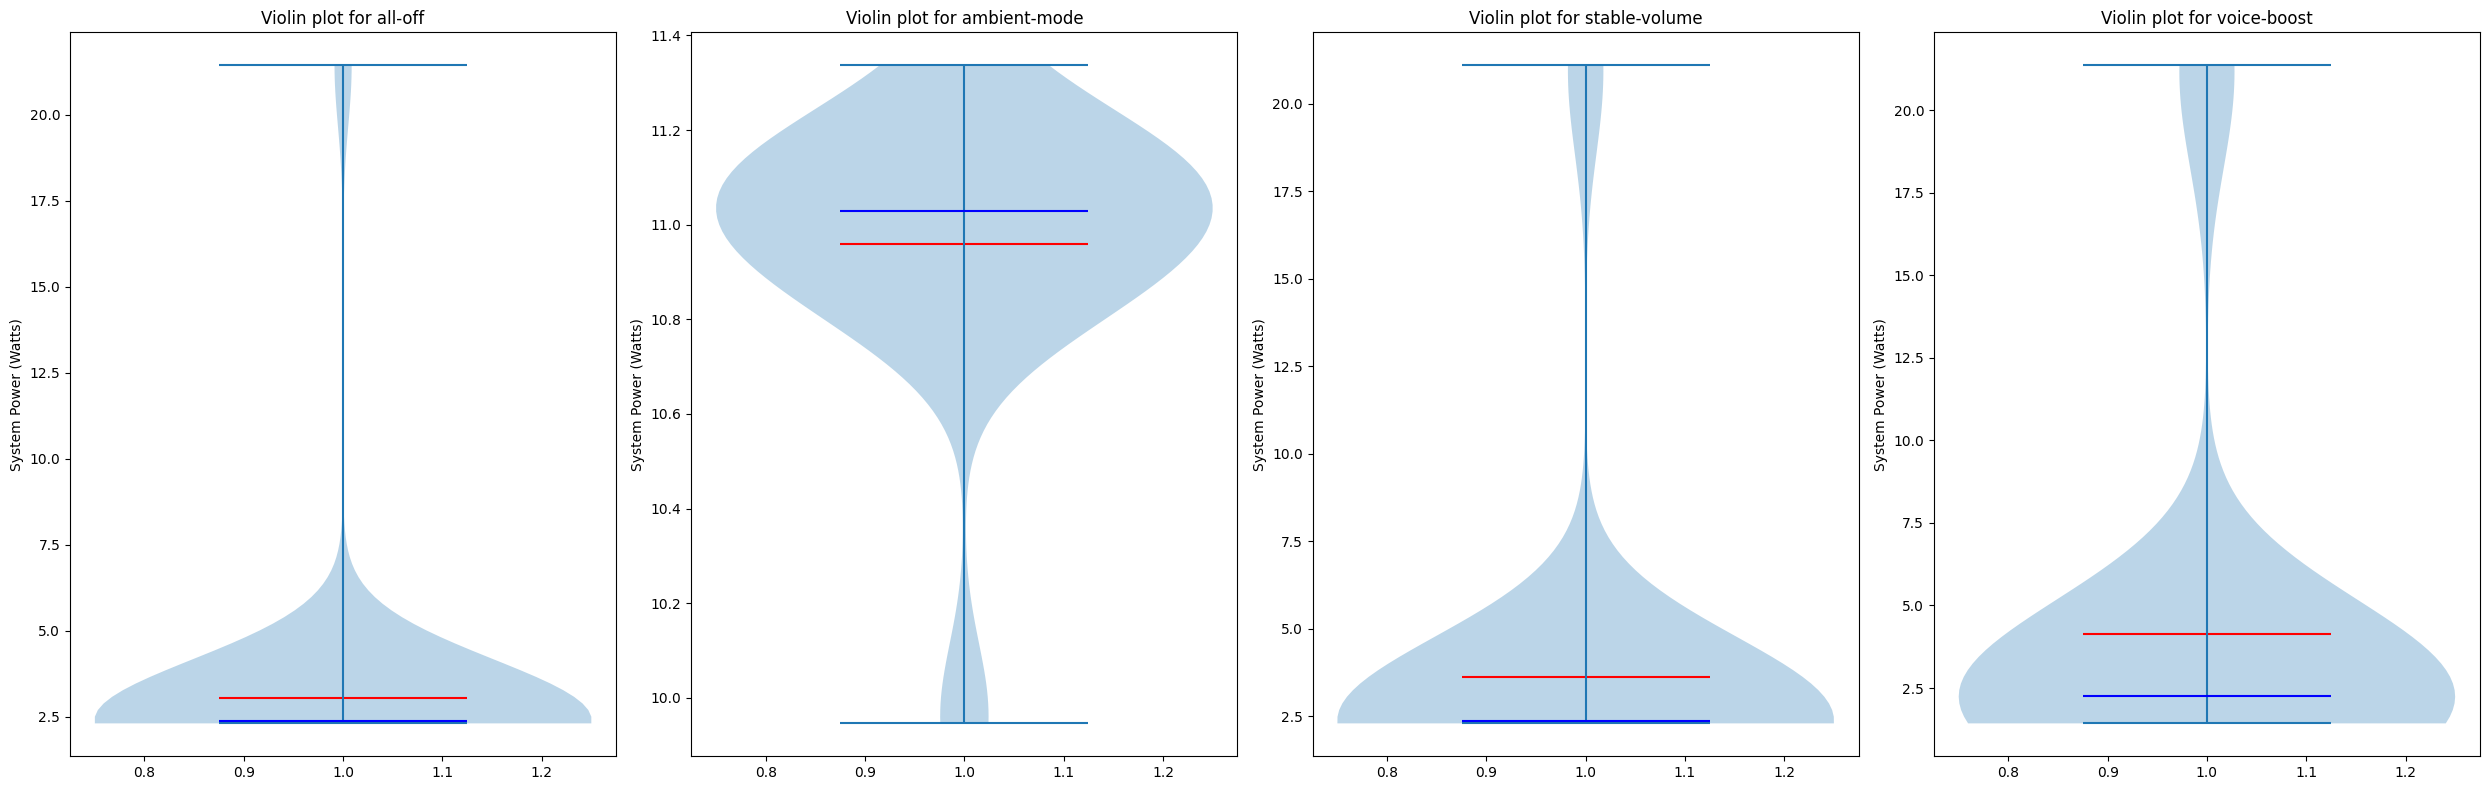

In [1097]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(avg_df[f], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

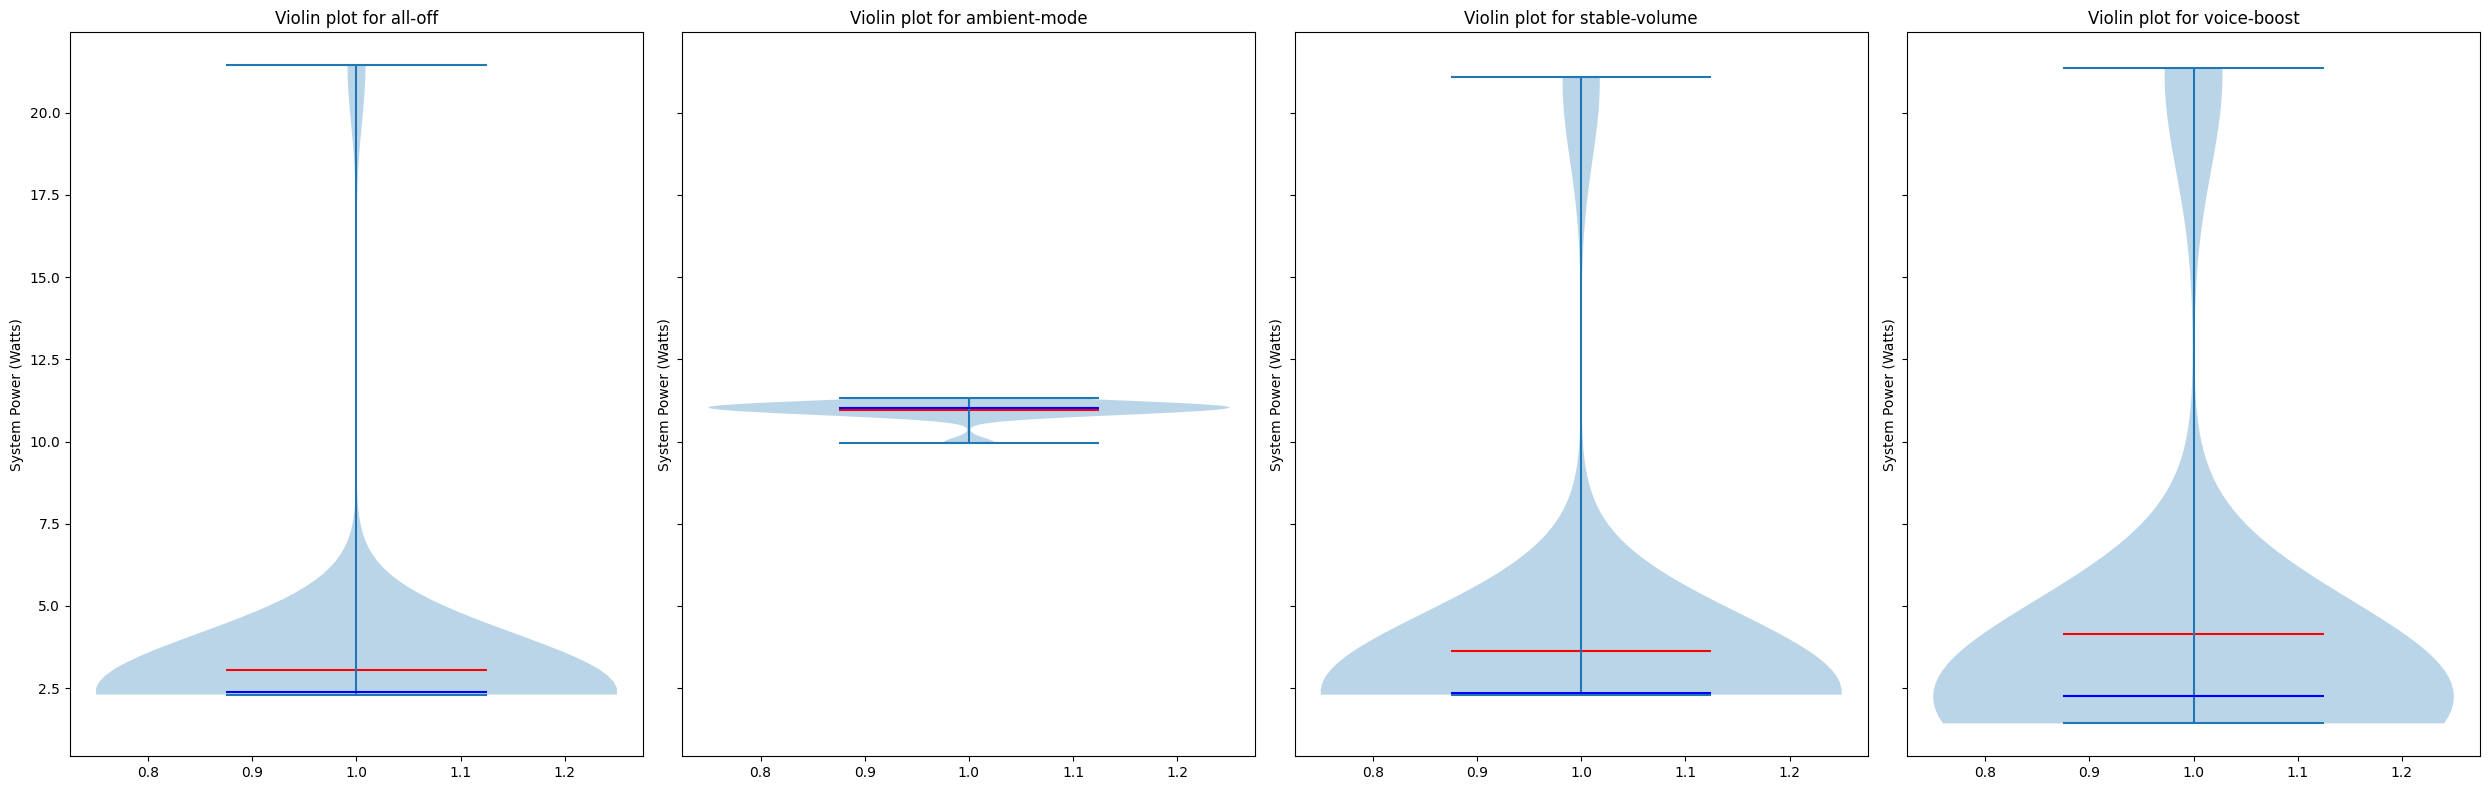

In [1098]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)),
                            sharey=True)
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(avg_df[f], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

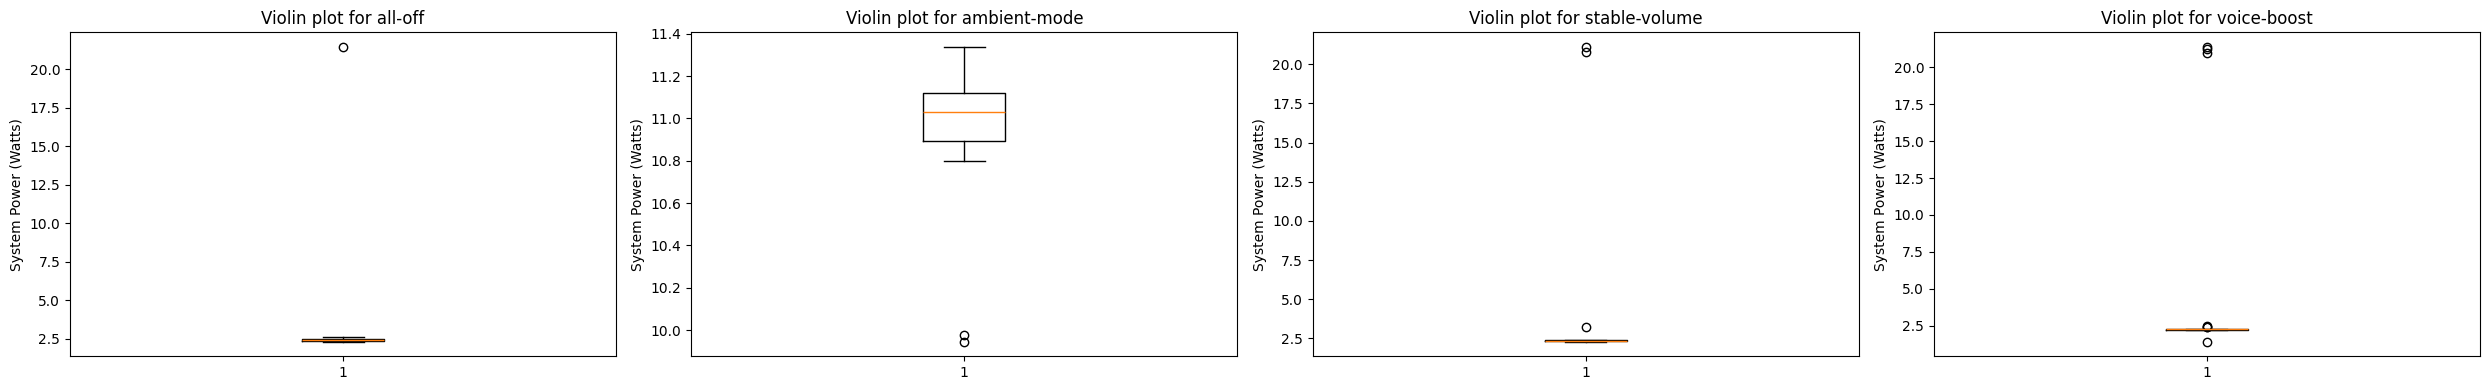

In [1099]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(avg_df[f])
    
plt.tight_layout()
plt.show()

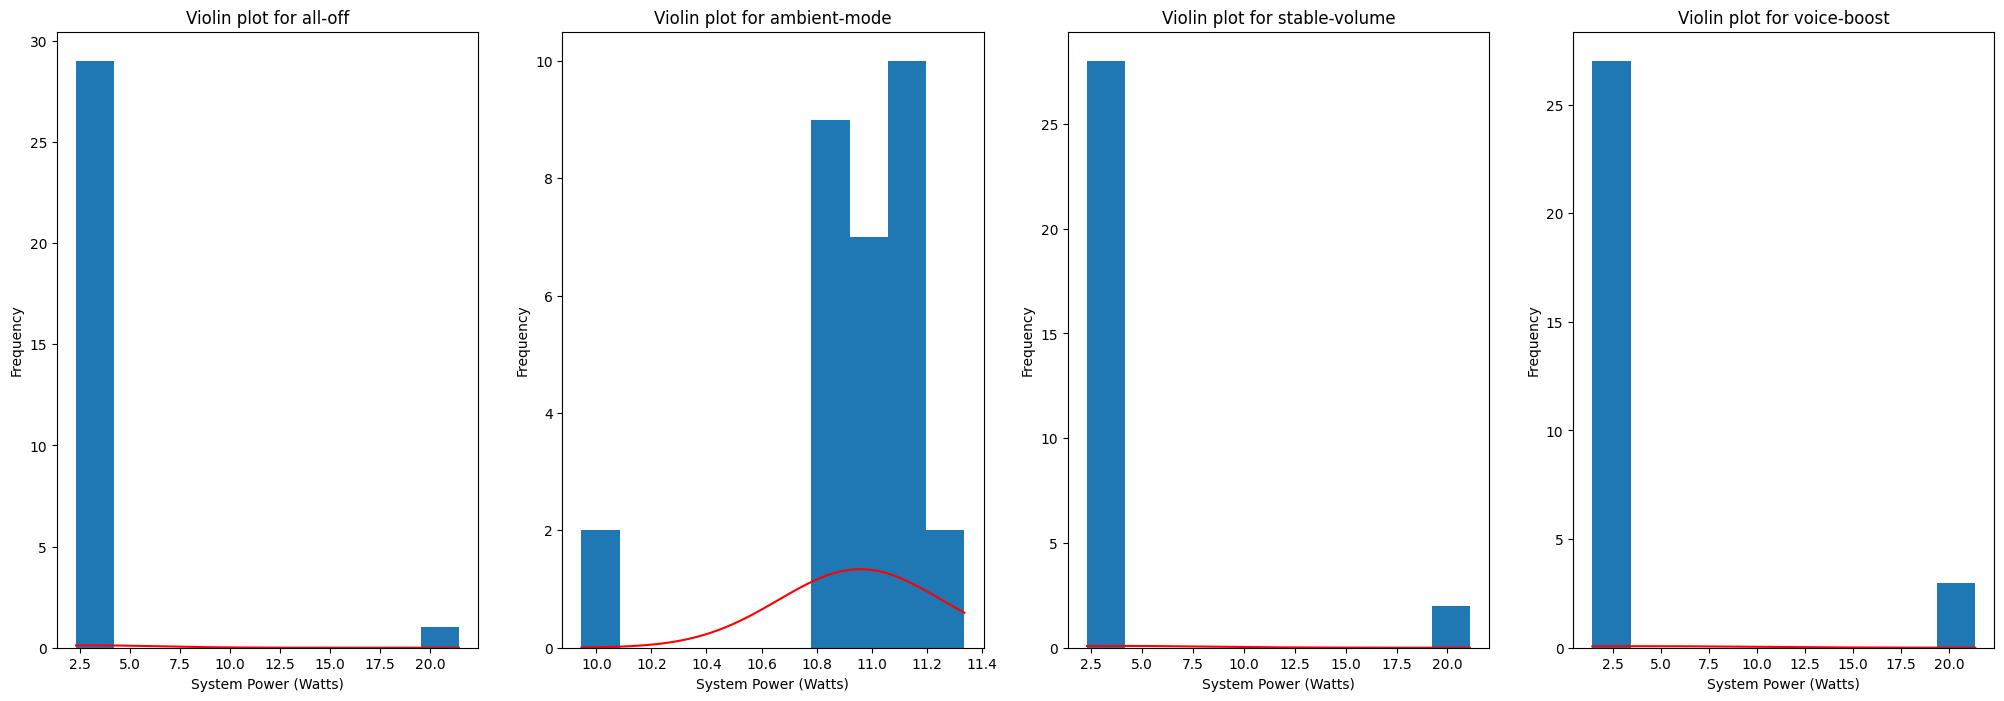

In [1100]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(avg_df[f], density=False)
    mu, std = norm.fit(avg_df[f])
    x = np.linspace(avg_df[f].min(), avg_df[f].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

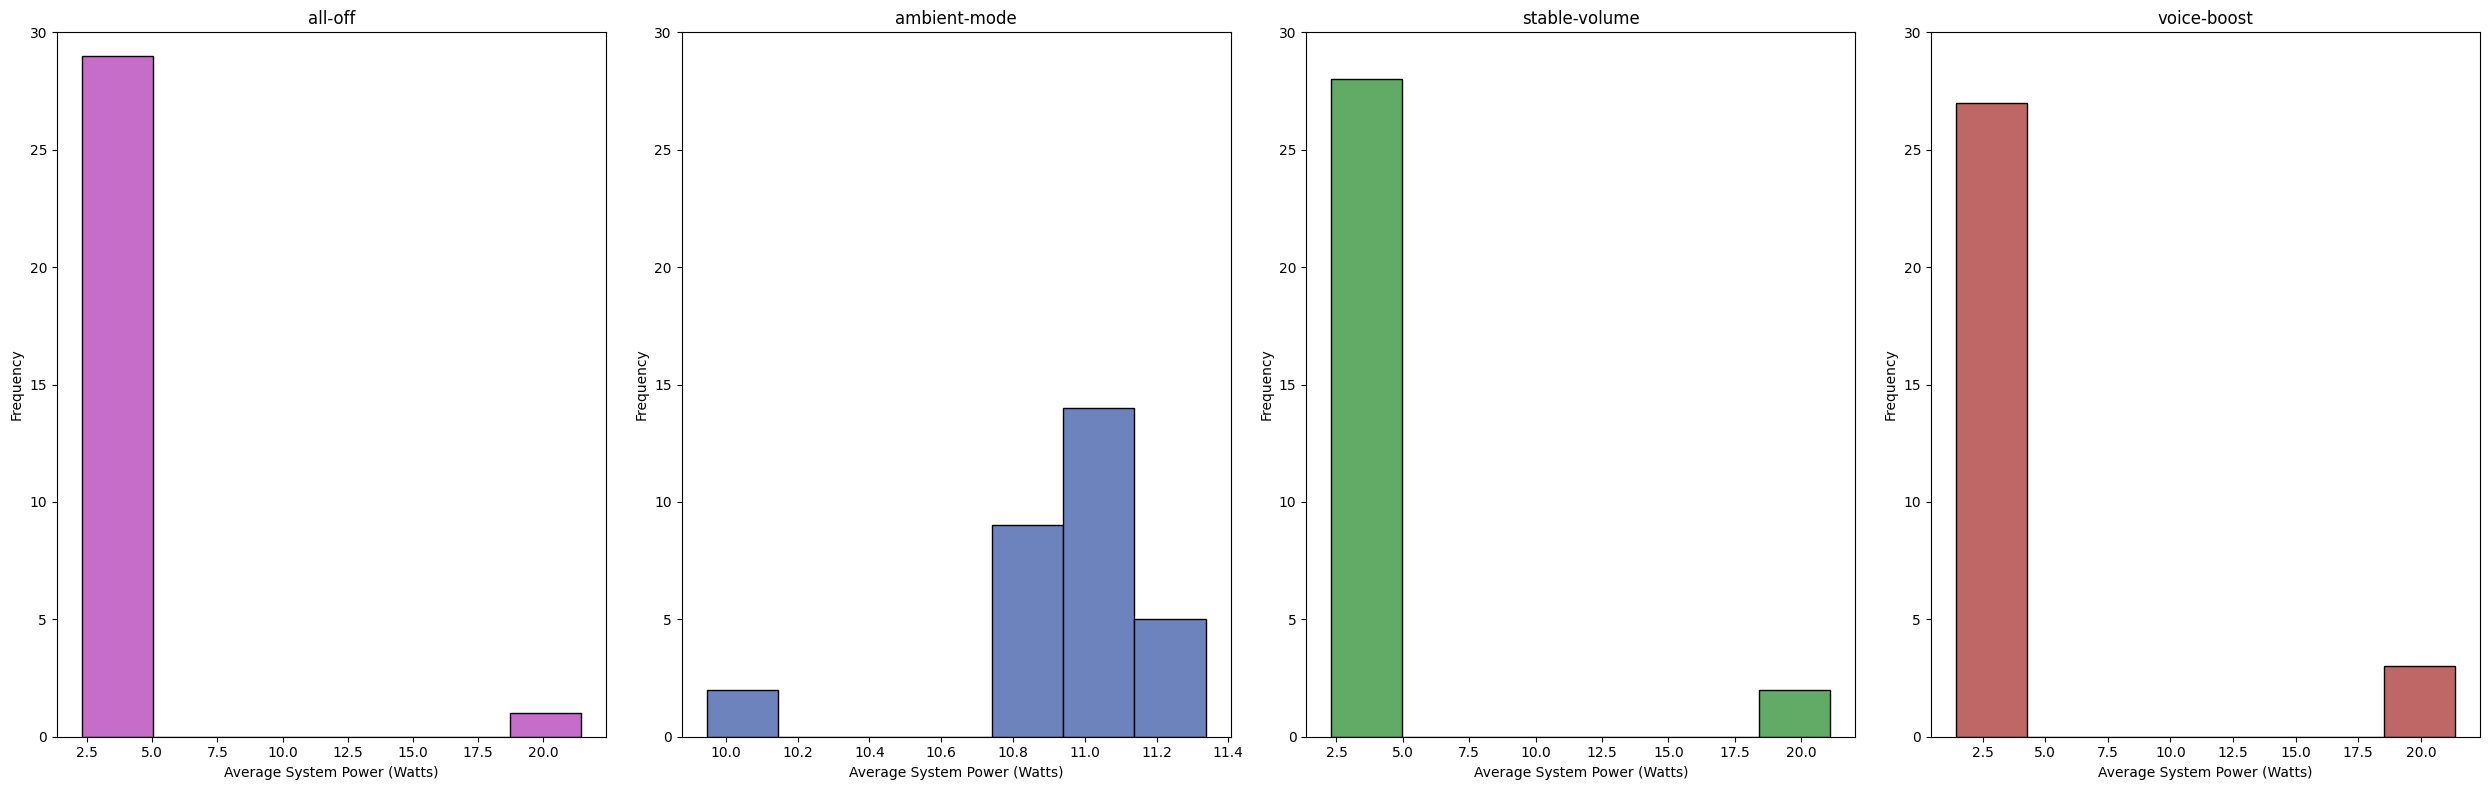

In [1101]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

colors = ["#c56dc8", "#6d83bd", "#61ab67", "#bf6767"]

fig, plots = plt.subplots(
    nrows=1,
    ncols=len(QUALITY_DIRECTORIES),
    figsize=(25, 2 * len(QUALITY_DIRECTORIES))
)

plots = plots.flatten()

for idx, (f, color) in enumerate(zip(QUALITY_DIRECTORIES, colors)):
    ax = plots[idx]

    ax.set_title(f"{f}")
    ax.set_xlabel("Average System Power (Watts)")
    ax.set_ylabel("Frequency")

    # Histogram with matching violin color
    counts, bins, patches = ax.hist(
        avg_df[f],
        bins=7,
        density=False,
        color=color,
        edgecolor="black",
    )

    ax.set_ylim(0, 30)



plt.tight_layout()
plt.show()

### Normalised Average Results 

In [1102]:
for f in avg_df.columns:
    stats, p_val = shapiro(avg_df[f])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.0273136909214146e-11, the data in all-off is NOT NORMAL
With p-val 2.2635137372250467e-06, the data in ambient-mode is NOT NORMAL
With p-val 5.94505968096356e-11, the data in stable-volume is NOT NORMAL
With p-val 2.770963439431905e-10, the data in voice-boost is NOT NORMAL


In [1103]:
# norm_avg_df = {}
# for i, f in enumerate(QUALITY_DIRECTORIES):
#     mean = avg_df[f].mean()
#     std = avg_df[f].std()
#     outlier = []
#     max_diff = 0
#     print(f"3x std: {3 * std} | mean: {mean}")
#     for idx, val in enumerate(avg_df[f]): 
#         diff = mean - val
#         abs_diff = np.abs(diff)
#         if abs_diff > max_diff: max_diff = abs_diff
#         if abs_diff > 3*std: 
#             print(f"Found outlier at {idx}")
#             outlier.append(idx)

#     print(f"Maximum difference found: {max_diff}")
#     n_df = avg_df[f].drop(avg_df[f].index[outlier])
#     norm_avg_df[f] = n_df
#     print("===============================================")
# norm_avg_df = pd.DataFrame(norm_avg_df)
# norm_avg_df

In [1104]:
norm_avg_df = {}
for f in QUALITY_DIRECTORIES:
    series = avg_df[f]
    
    # Calculate Quartiles
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds (1.5 is standard, use 3.0 for "extreme" outliers only)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter data
    n_df = series[(series >= lower_bound) & (series <= upper_bound)]
    
    norm_avg_df[f] = n_df
    
    print(f"Range for {f}: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Dropped {len(series) - len(n_df)} outliers")
    print("===============================================")

norm_avg_df = pd.DataFrame(norm_avg_df)
norm_avg_df


Range for all-off: [2.18, 2.65]
Dropped 1 outliers
Range for ambient-mode: [10.56, 11.46]
Dropped 2 outliers
Range for stable-volume: [2.25, 2.47]
Dropped 3 outliers
Range for voice-boost: [2.12, 2.40]
Dropped 7 outliers


,all-off,ambient-mode,stable-volume,voice-boost
0,2.385781,11.128990,2.371276,2.288264
1,2.376407,10.904376,2.395648,2.227329
2,2.410846,11.087791,2.386488,NaN
3,2.560027,10.894909,NaN,2.222864
4,2.509512,11.057210,NaN,2.222439
5,2.353514,10.897482,2.386653,NaN
6,2.363049,10.852537,2.333410,2.181522
7,2.321899,11.277278,2.367959,2.283809
8,2.341999,11.336967,2.331962,2.224439
9,2.351187,11.122805,2.354925,2.297361


In [1105]:
for f in norm_avg_df.columns:
    stats, p_val = shapiro(norm_avg_df[f].dropna())
    

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 0.0005650693156837157, the data in all-off is NOT NORMAL
With p-val 0.41224497695592466, the data in ambient-mode is NORMAL
With p-val 0.24914264595332794, the data in stable-volume is NORMAL
With p-val 0.6870279083141211, the data in voice-boost is NORMAL


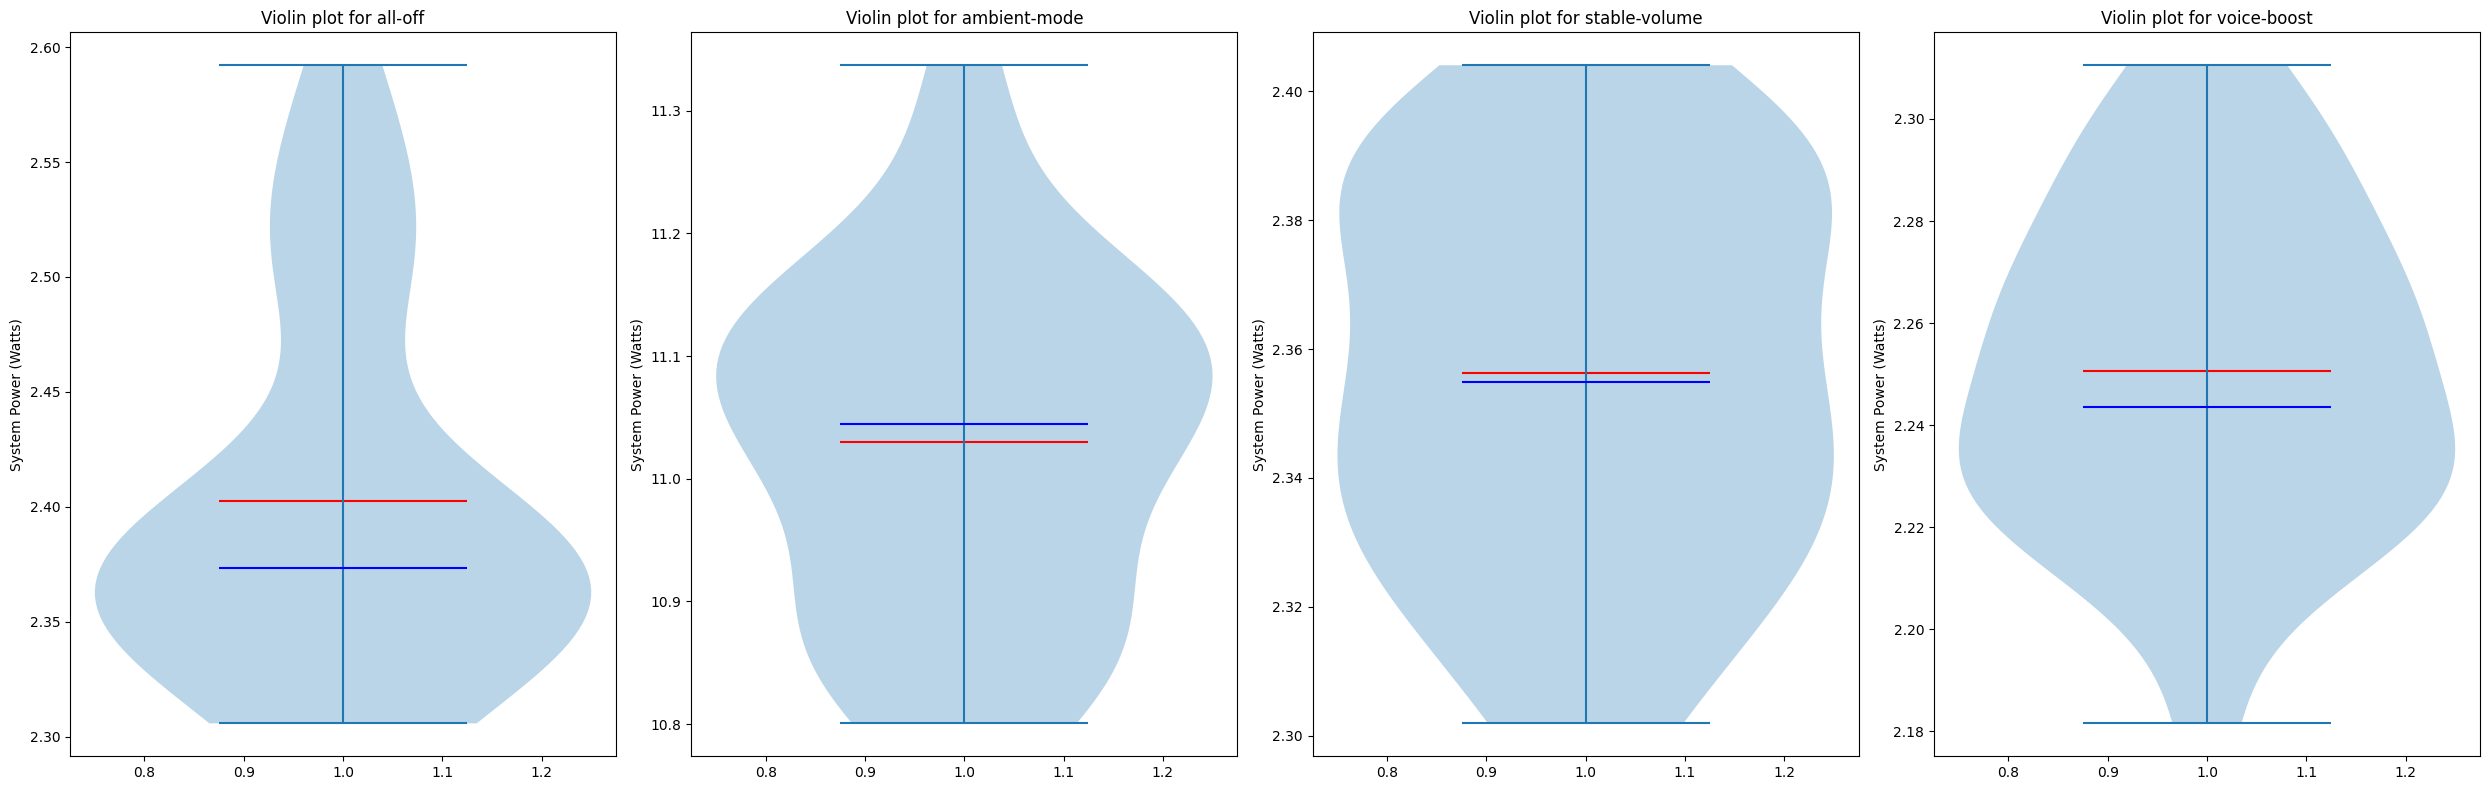

In [1106]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_avg_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


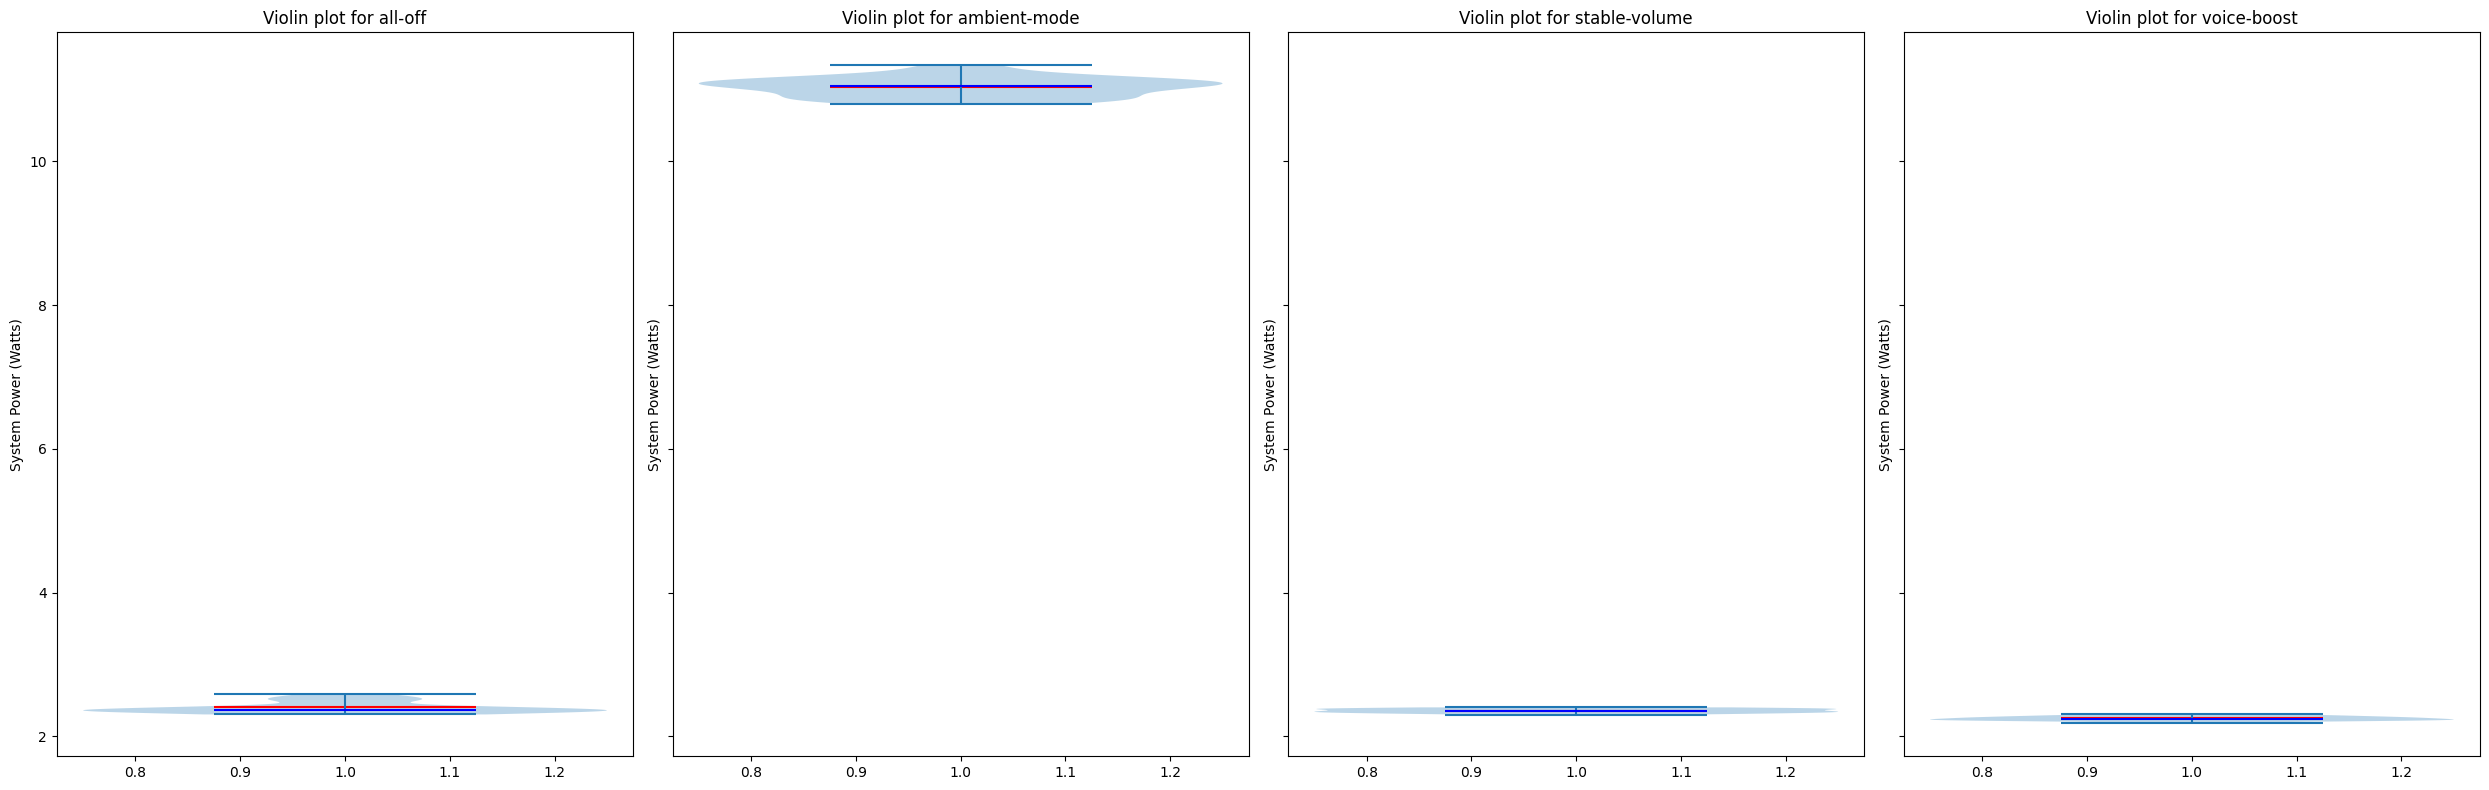

In [1107]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)),
                            sharey=True)
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]

    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_avg_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


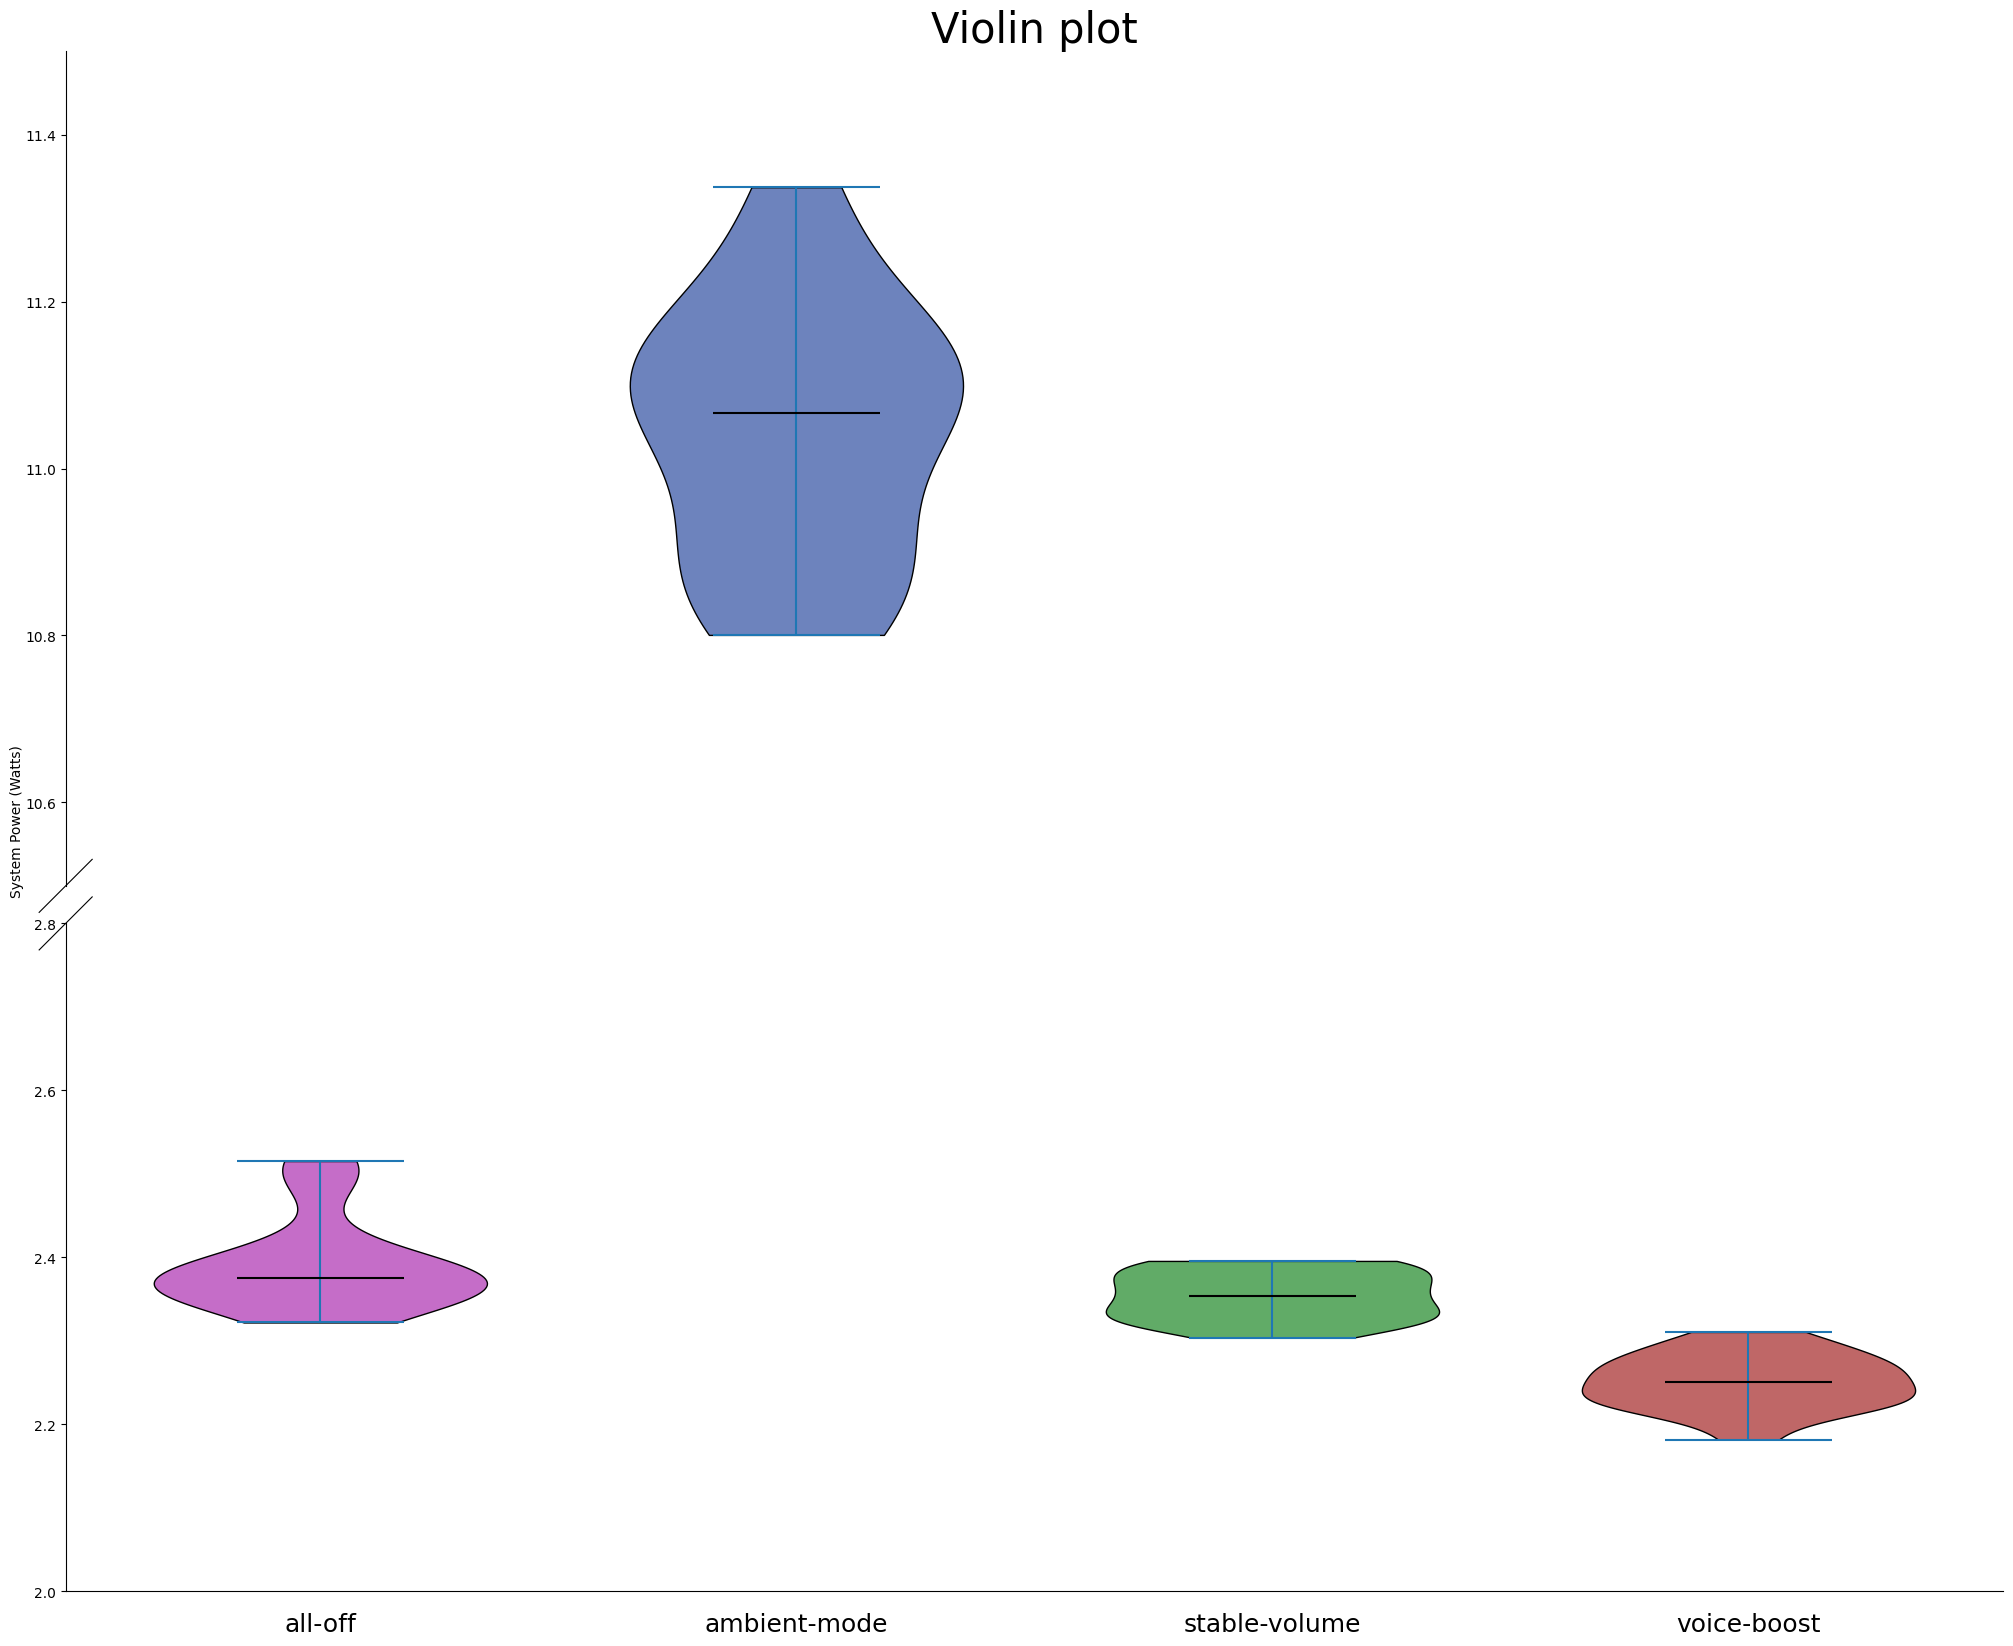

In [1122]:
fig = plt.figure(figsize=(25, 20))

bax = brokenaxes(
    ylims=((2.0, 2.8), (10.5, 11.5)),
    hspace=0.05,
    fig=fig
)

bax.set_title("Violin plot", fontsize=30, fontweight=400)
bax.set_ylabel("System Power (Watts)")

parts = bax.violinplot(
    norm_avg_df.dropna(),
    showmedians=True, widths=0.7
)

colors = ["#c56dc8", "#6d83bd", "#61ab67", "#bf6767"]

# Style violins
for ax_parts in parts:
    ax_parts['cmedians'].set_color('#000000')
    for body, color in zip(ax_parts['bodies'], colors):
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(1)  # fully opaque


# Remove grid
bax.grid(False)

# Proper x-axis labels (no numbers)
positions = range(1, len(norm_avg_df.columns) + 1)

for ax in bax.axs:
    ax.set_xticks(positions)
    ax.set_xticklabels(norm_avg_df.columns, fontsize=18)
    ax.tick_params(axis='x', length=0, pad=15)  # remove tick marks + push labels down

plt.show()

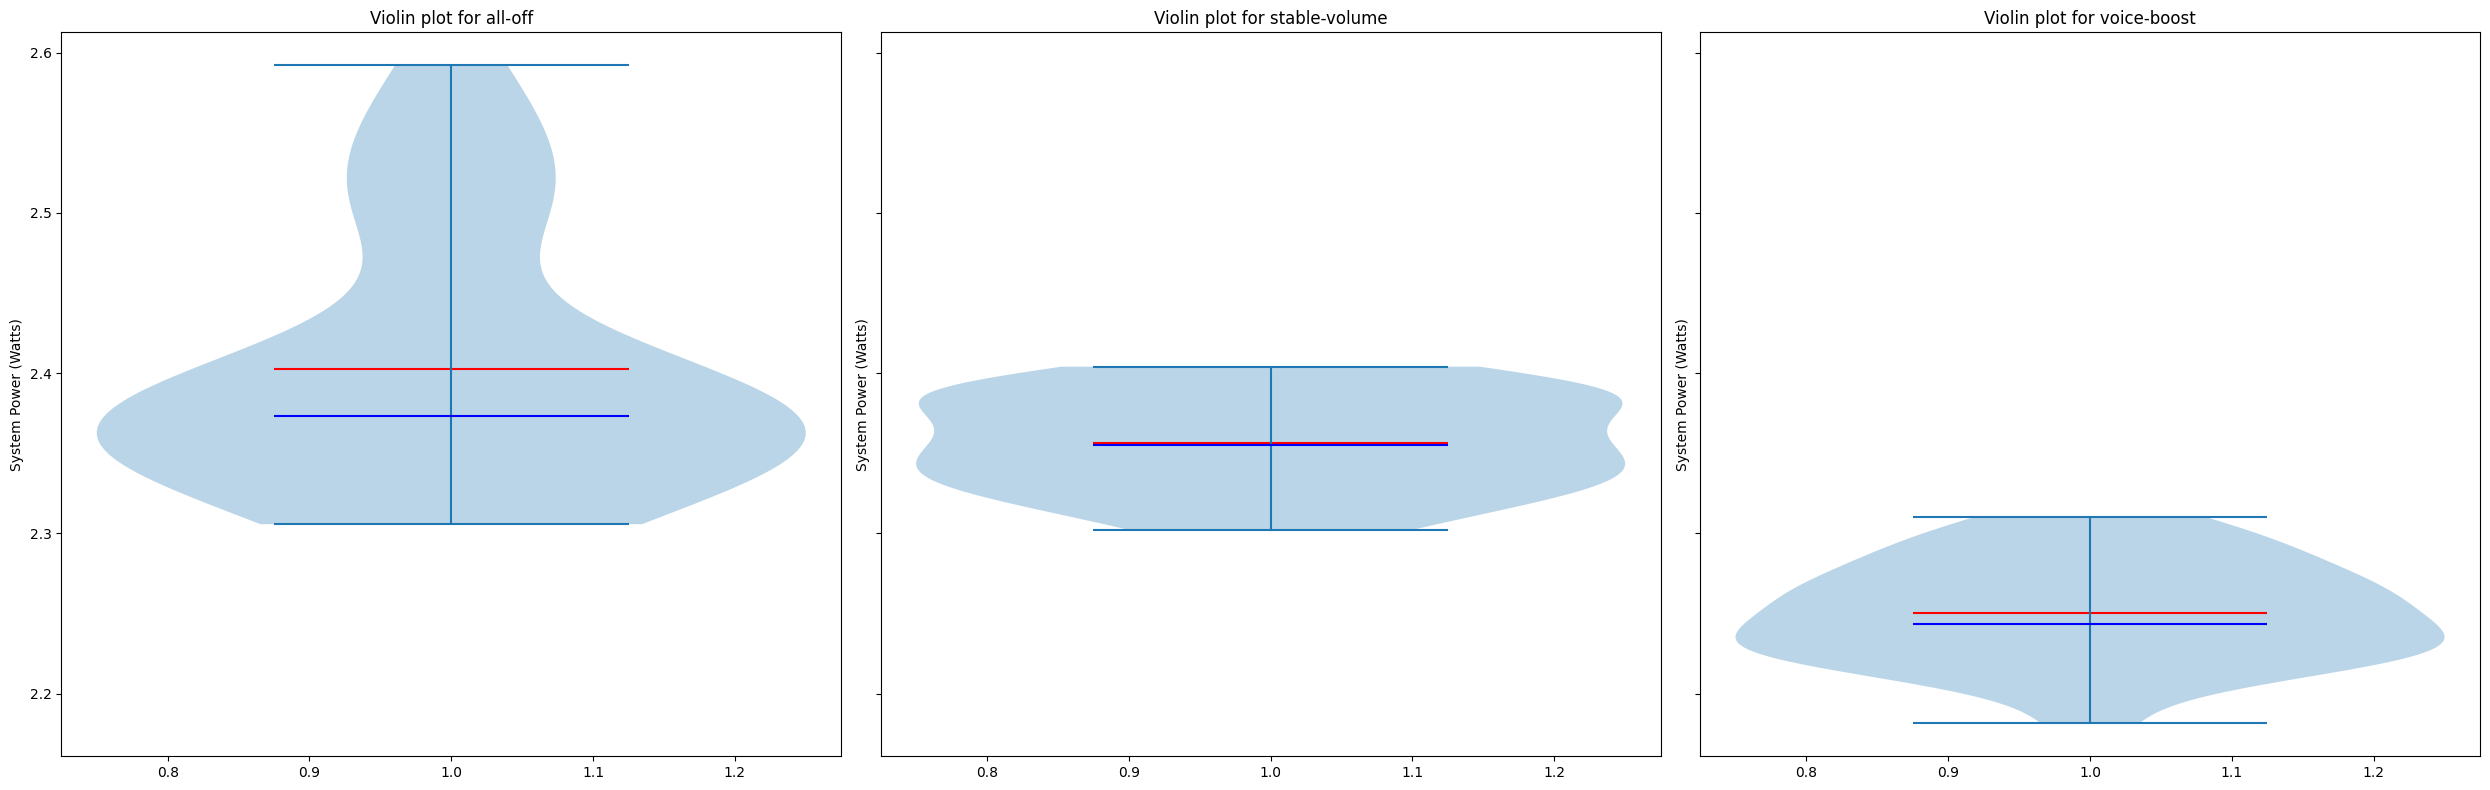

In [1109]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES)-1,
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)),
                            sharey=True)
plots = plots.flatten()

for idx, f in enumerate(x for x in QUALITY_DIRECTORIES if x != 'ambient-mode'):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_avg_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


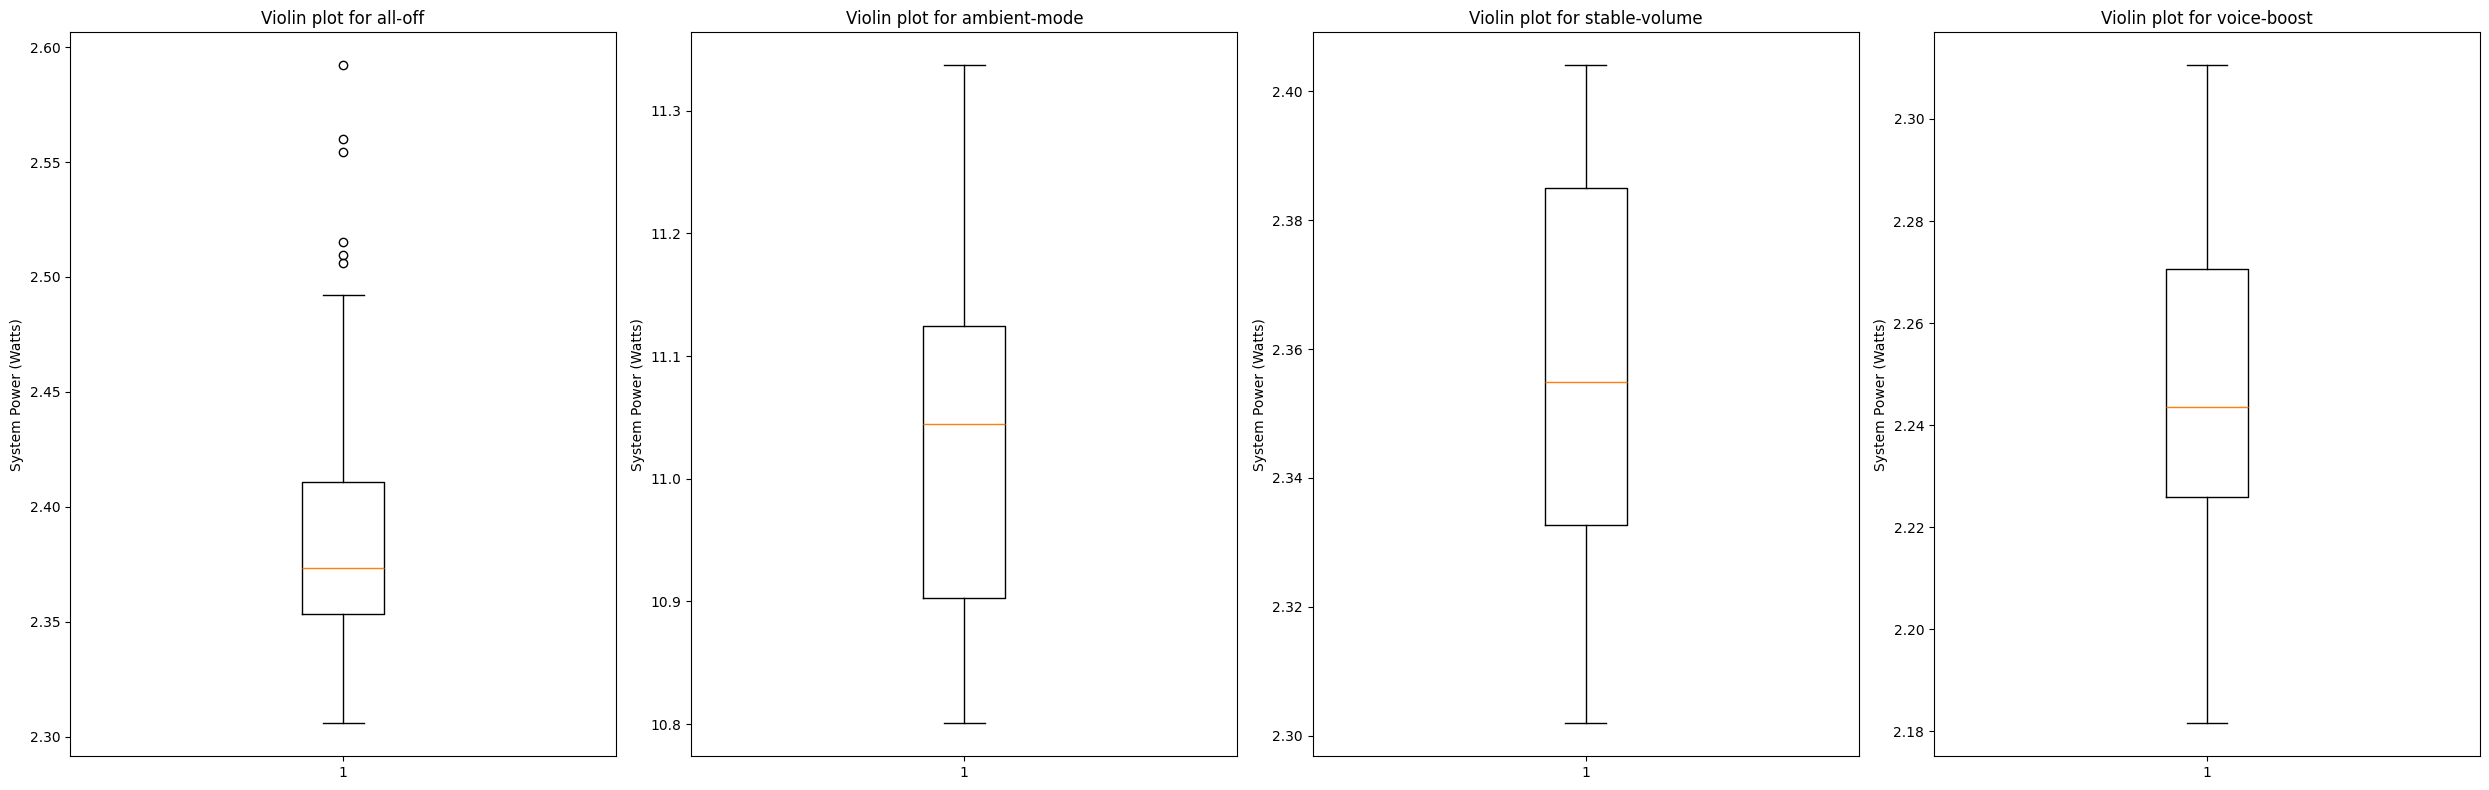

In [1110]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2*len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(norm_avg_df[f].dropna())
    
plt.tight_layout()
plt.show()

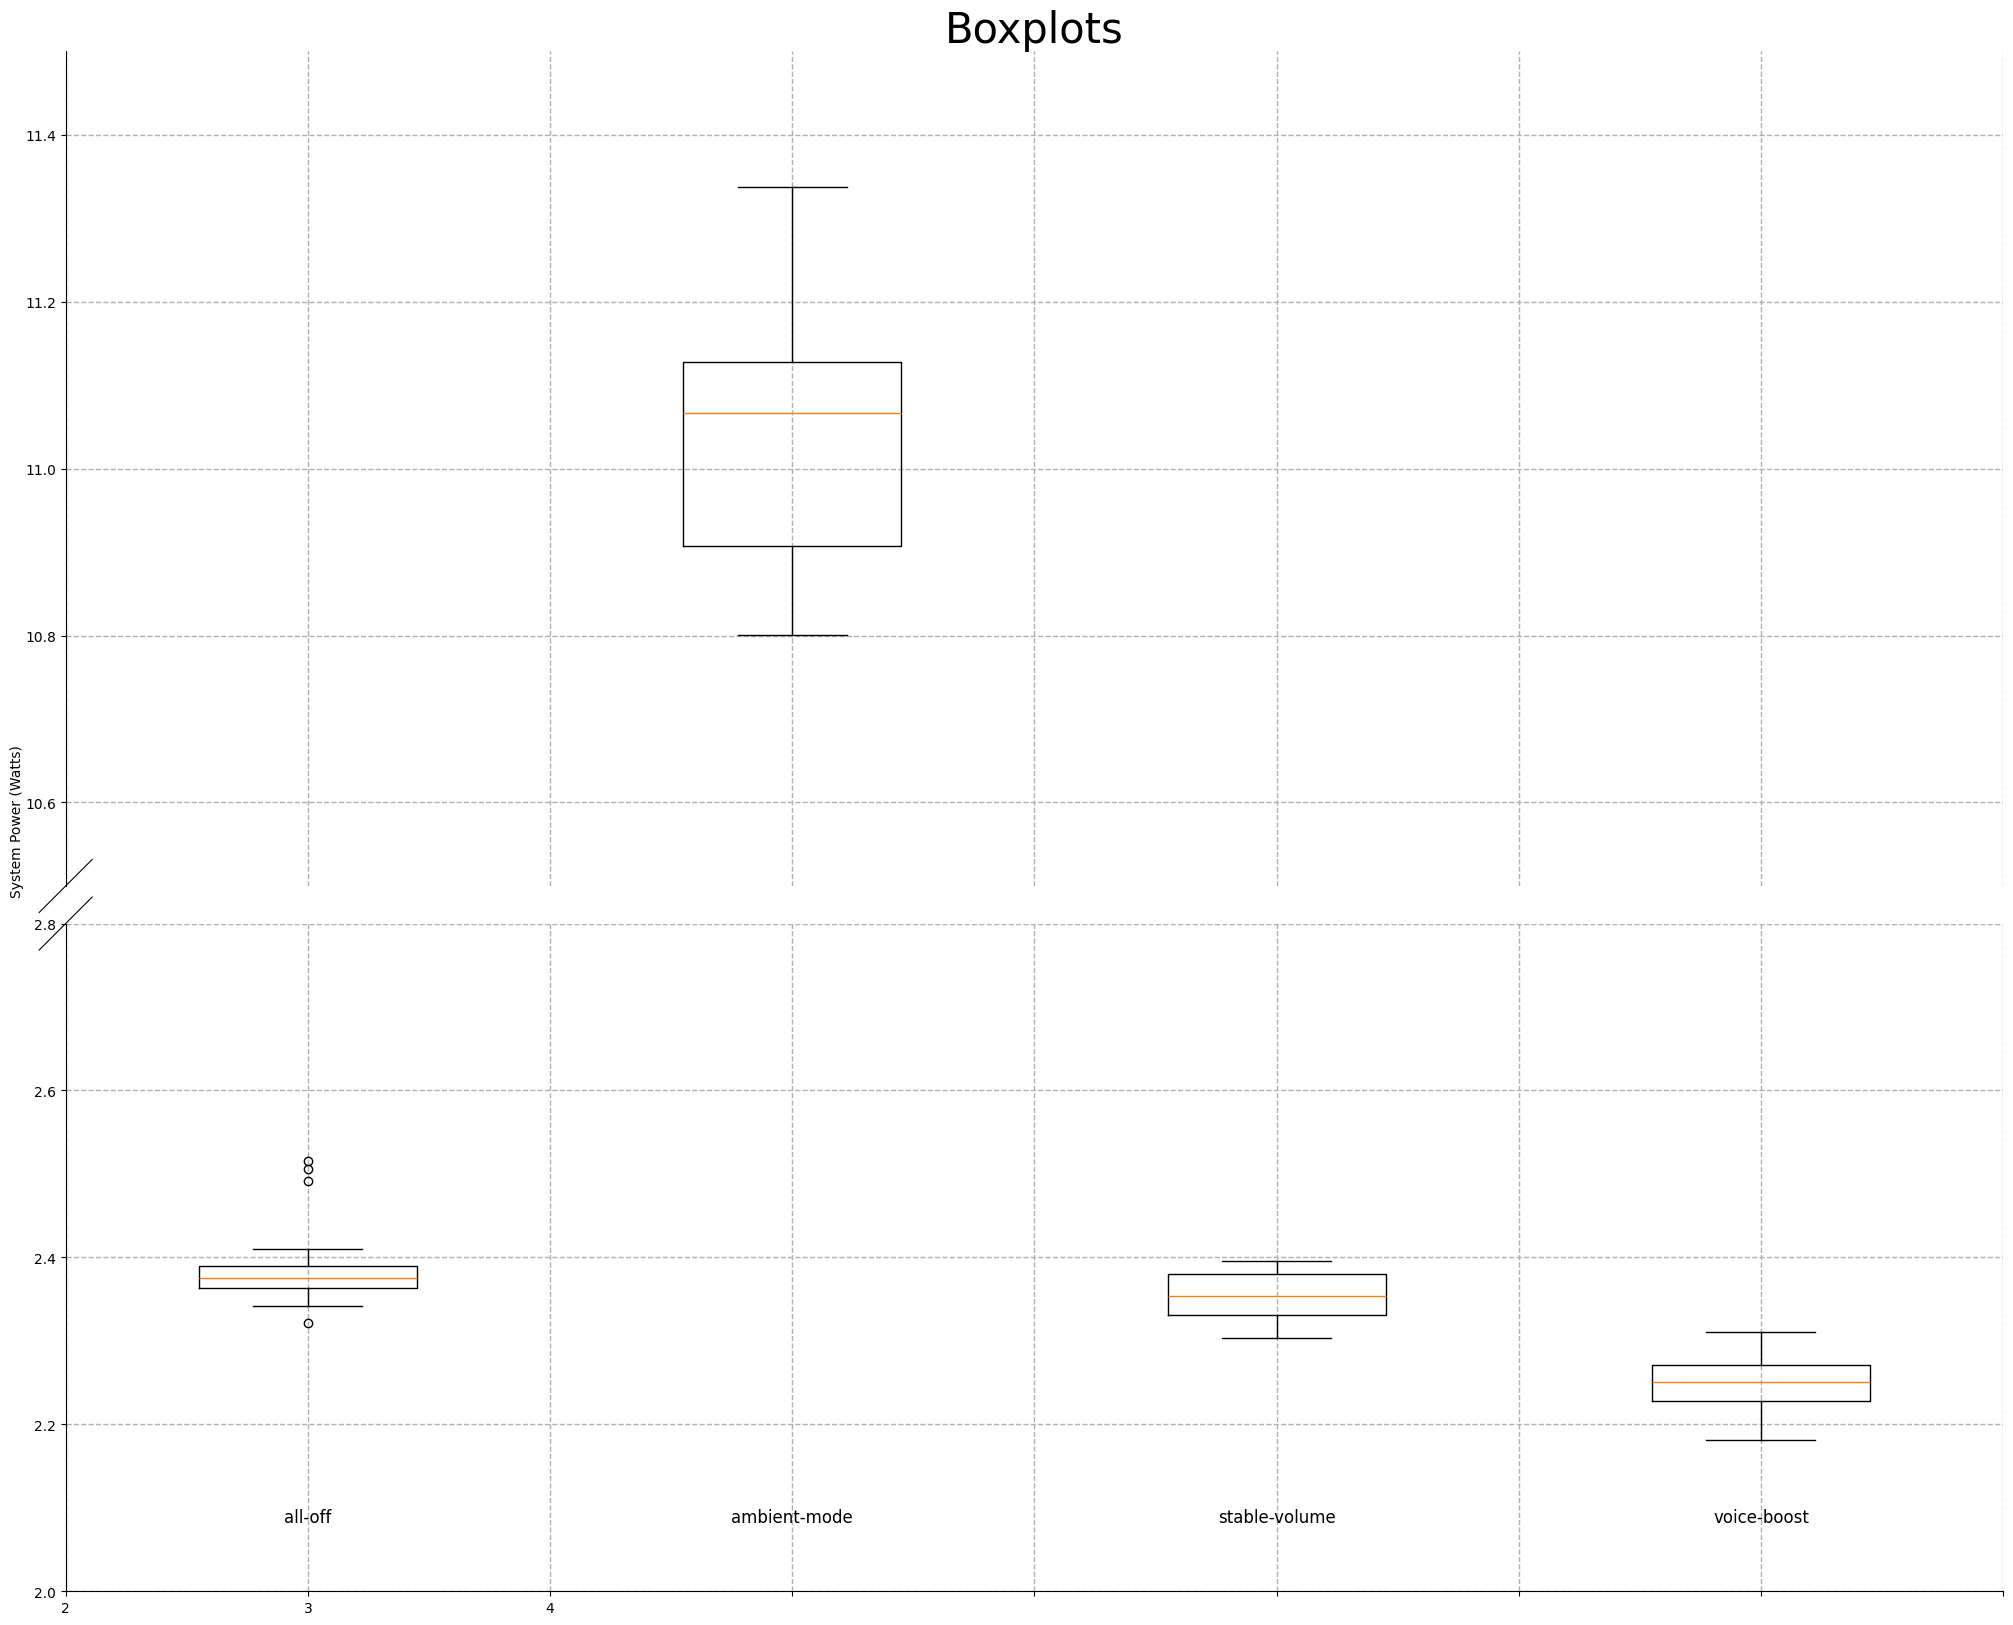

In [1111]:
fig = plt.figure(figsize=(25, 20))

bax = brokenaxes(
                ylims=((2,2.8), (10.5,11.5)), 
                hspace=0.05,
                fig=fig)
bax.set_title(f"Boxplots", fontsize=30, fontweight=400)
bax.set_ylabel('System Power (Watts)')
bax.boxplot(norm_avg_df.dropna())
bax.grid(True, linewidth=1, linestyle='--')
position = list(range(1, len(norm_avg_df) + 1))
for pos, col in zip(position, norm_avg_df.columns): 
    bax.text(pos, 2.1, col, ha='center', va='top', rotation=0, fontsize=12)
                
plt.show()

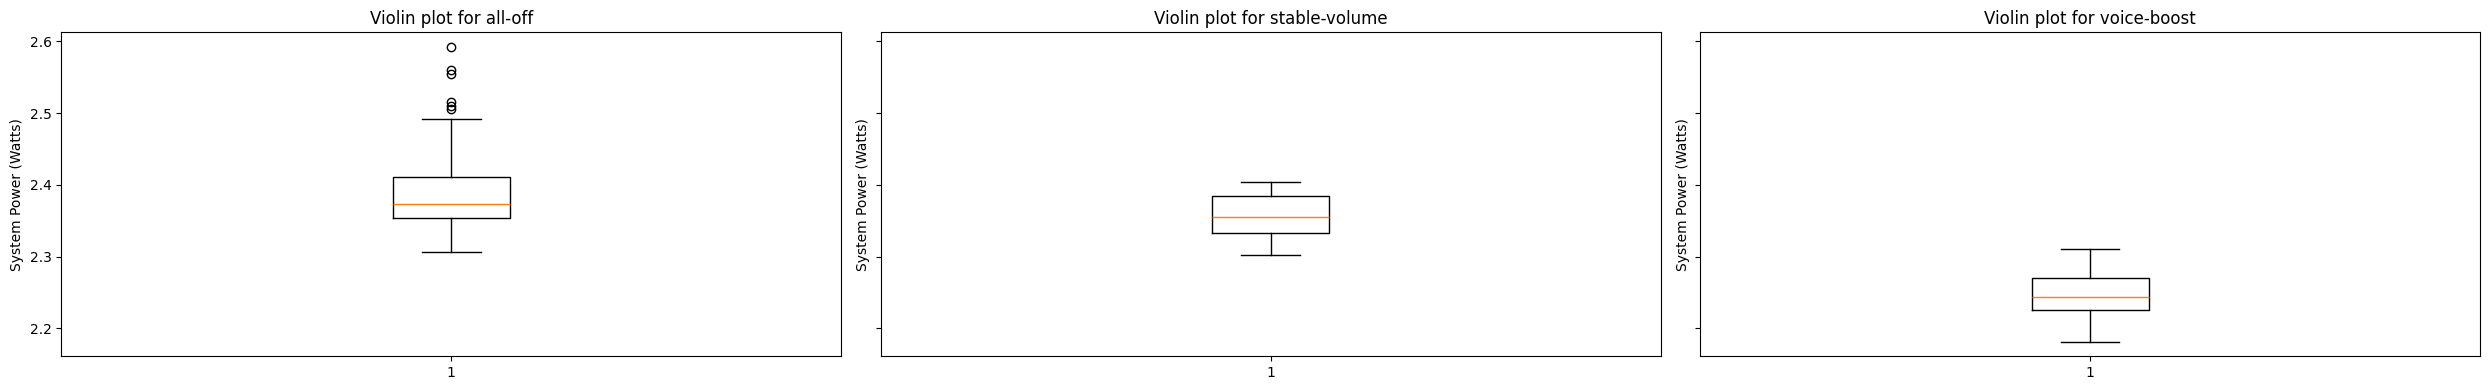

In [1112]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES)-1,
                            figsize =(25, len(QUALITY_DIRECTORIES)),
                            sharey = True)
plots = plots.flatten()

for idx, f in enumerate(x for x in QUALITY_DIRECTORIES if x != 'ambient-mode'):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(norm_avg_df[f].dropna())
    
plt.tight_layout()
plt.show()

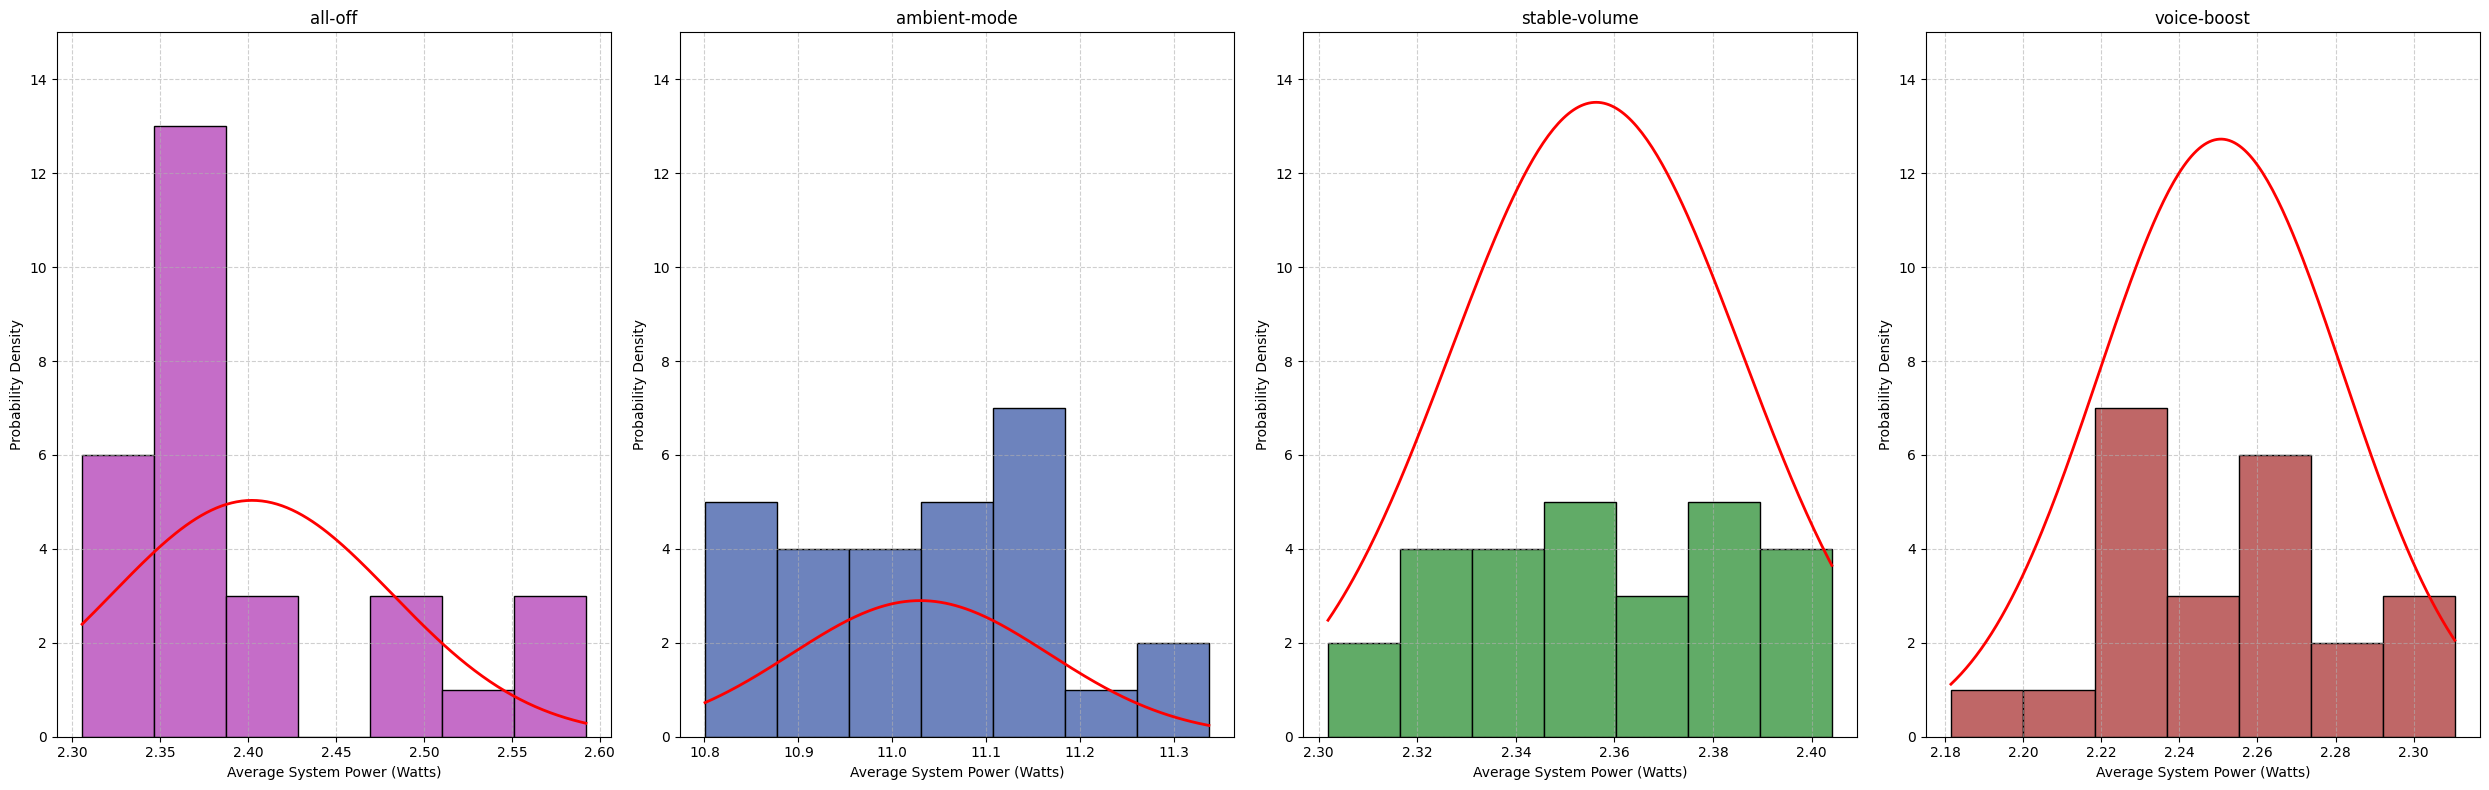

In [1113]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

colors = ["#c56dc8", "#6d83bd", "#61ab67", "#bf6767"]

fig, plots = plt.subplots(
    nrows=1,
    ncols=len(QUALITY_DIRECTORIES),
    figsize=(25, 2 * len(QUALITY_DIRECTORIES))
)

plots = plots.flatten()

for idx, (f, color) in enumerate(zip(QUALITY_DIRECTORIES, colors)):
    ax = plots[idx]

    data = norm_avg_df[f].dropna()

    ax.set_title(f"{f}")
    ax.set_xlabel("Average System Power (Watts)")
    ax.set_ylabel("Probability Density")

    # Density histogram with matching violin color
    ax.hist(
        data,
        bins=7,
        density=False,
        color=color,
        edgecolor="black",
    )

    # Fit and plot normal PDF
    mu, std = norm.fit(data)
    x = np.linspace(data.min(), data.max(), 200)
    p = norm.pdf(x, mu, std)

    ax.plot(x, p, color="red", linewidth=2)

    ax.grid(True, linestyle="--", alpha=0.6)

    ax.set_ylim(0, 15)


plt.tight_layout()
plt.show()

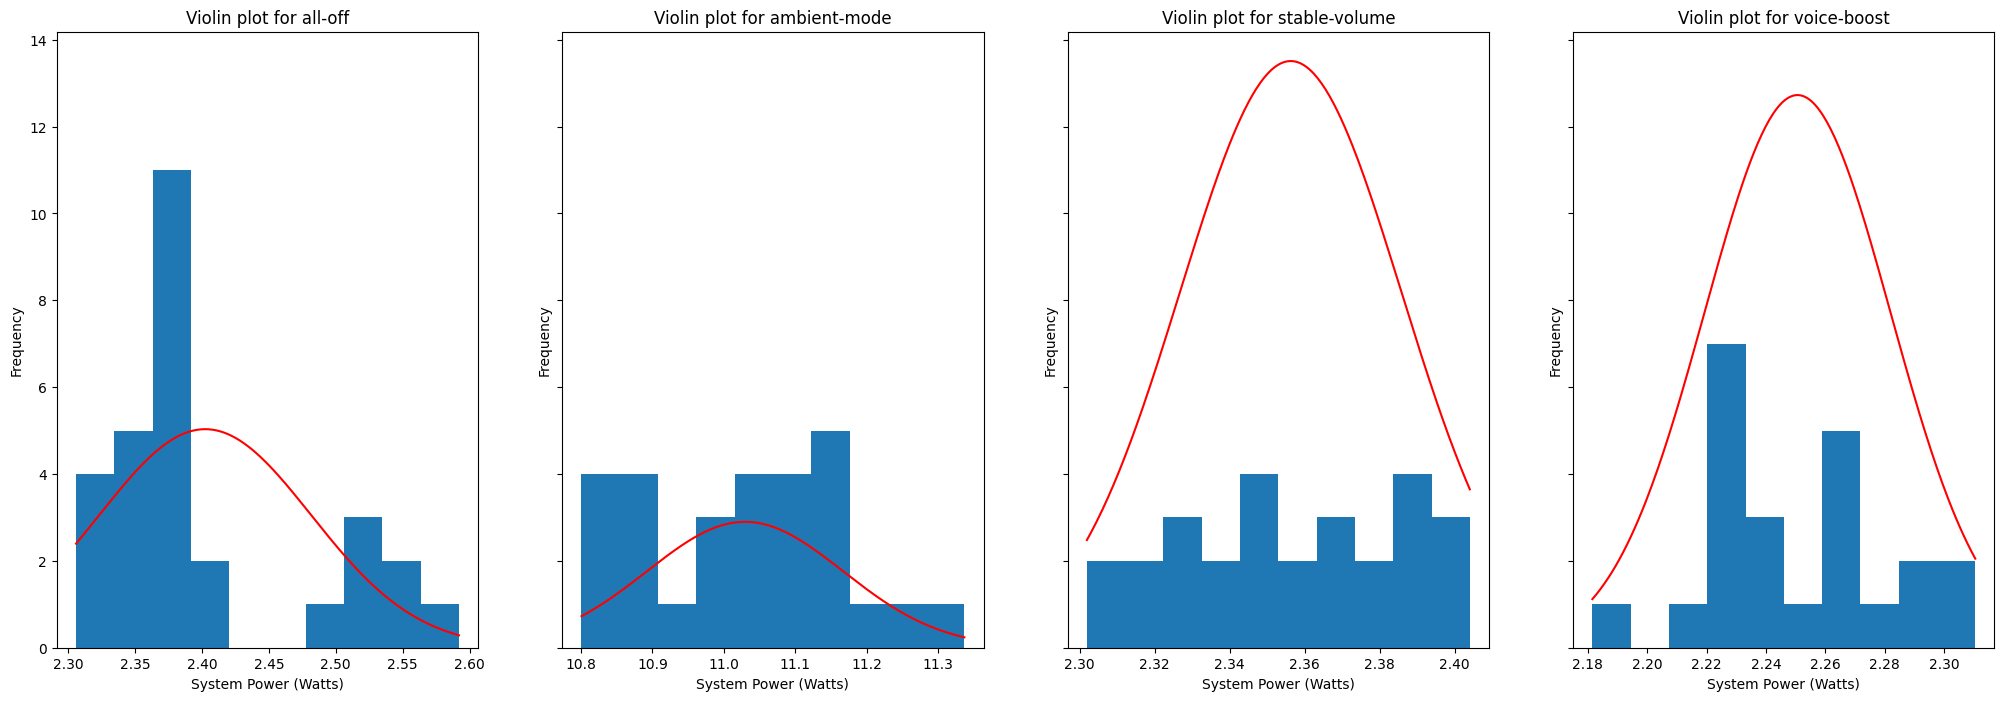

In [1114]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)),
                            sharey=True)
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(norm_avg_df[f].dropna(), )
    mu, std = norm.fit(norm_avg_df[f].dropna())
    x = np.linspace(norm_avg_df[f].dropna().min(), norm_avg_df[f].dropna().max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')
plt.show()

# Statistical Significances 

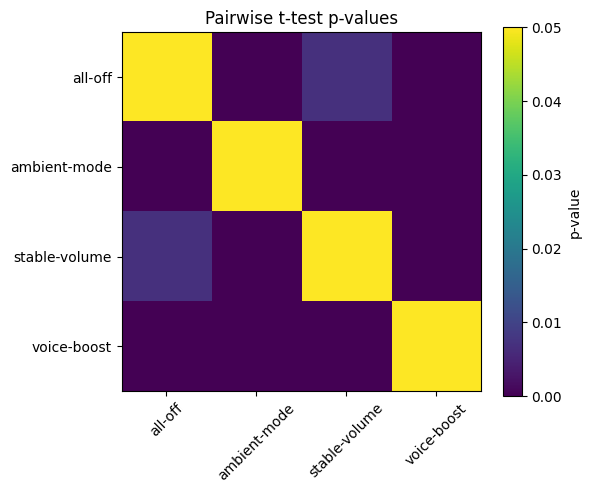

In [1115]:

cols = norm_avg_df.columns
pvals = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a = norm_avg_df[cols[i]].dropna()
        b = norm_avg_df[cols[j]].dropna()
        _, p = ttest_ind(a, b, equal_var=False)
        pvals.iloc[i, j] = p
        pvals.iloc[j, i] = p

plt.figure(figsize=(6, 5))
plt.imshow(pvals, vmin=0, vmax=0.05)
plt.colorbar(label="p-value")
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title("Pairwise t-test p-values")
plt.tight_layout()
plt.show()

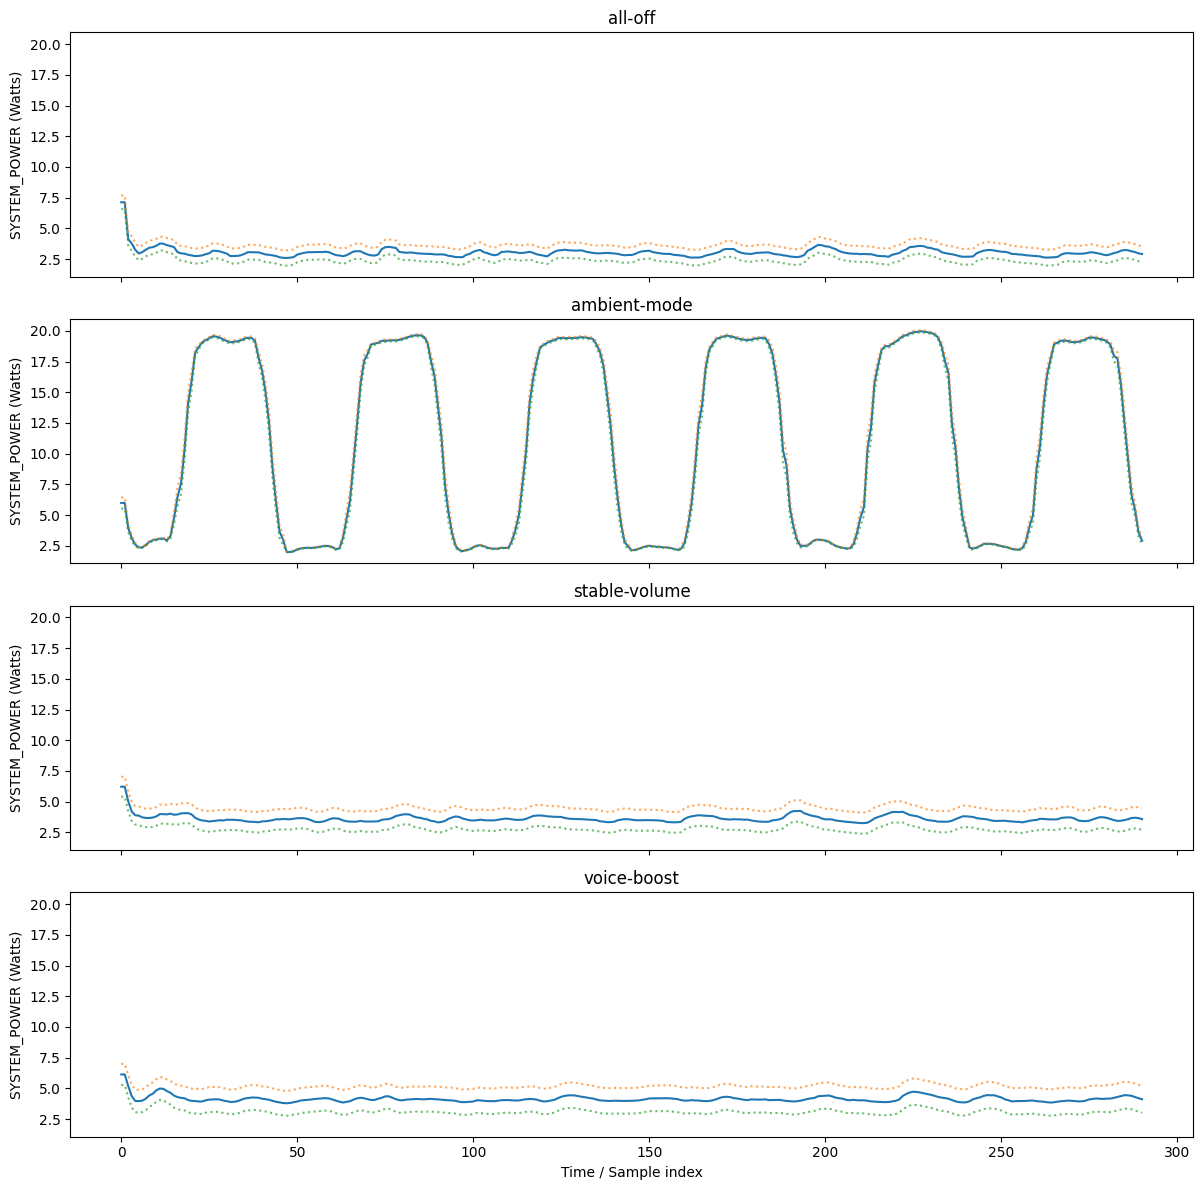

In [1116]:
groups = defaultdict(list)
for file, df in dataframes.items():
    key = file.split("/")[0]
    groups[key].append(df['SYSTEM_POWER (Watts)'].values)

keys = list(groups.keys())
fig, axes = plt.subplots(len(keys), 1, figsize=(12, 3*len(keys)), sharex=True, sharey=True)

for ax, key in zip(axes, keys):
    runs = groups[key]
    min_len = min(len(r) for r in runs)
    arr = np.vstack([r[:min_len] for r in runs])

    mean = arr.mean(axis=0)
    sem  = arr.std(axis=0) / np.sqrt(arr.shape[0])

    ax.plot(mean)
    ax.plot(mean + sem, linestyle=':', alpha=0.7)
    ax.plot(mean - sem, linestyle=':', alpha=0.7)
    ax.set_title(key)
    ax.set_ylabel("SYSTEM_POWER (Watts)")

axes[-1].set_xlabel("Time / Sample index")
plt.tight_layout()
plt.show()

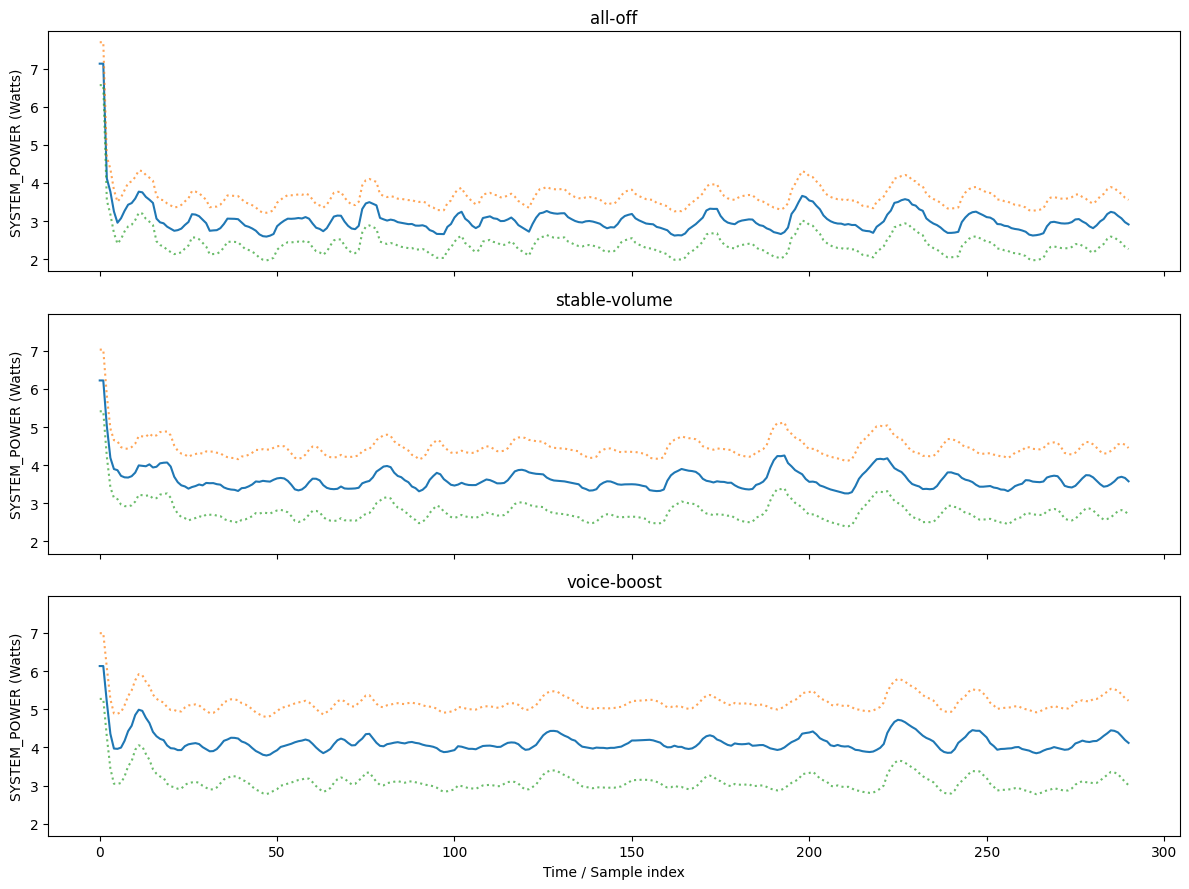

In [1117]:
groups = defaultdict(list)
for file, df in ((f, d) for f, d in dataframes.items() if 'ambient-mode' not in f):
    key = file.split("/")[0]
    groups[key].append(df['SYSTEM_POWER (Watts)'].values)

keys = list(groups.keys())
fig, axes = plt.subplots(len(keys), 1, figsize=(12, 3*len(keys)), sharex=True, sharey=True)

for ax, key in zip(axes, keys):
    runs = groups[key]
    min_len = min(len(r) for r in runs)
    arr = np.vstack([r[:min_len] for r in runs])

    mean = arr.mean(axis=0)
    sem  = arr.std(axis=0) / np.sqrt(arr.shape[0])

    ax.plot(mean)
    ax.plot(mean + sem, linestyle=':', alpha=0.7)
    ax.plot(mean - sem, linestyle=':', alpha=0.7)
    ax.set_title(key)
    ax.set_ylabel("SYSTEM_POWER (Watts)")

axes[-1].set_xlabel("Time / Sample index")
plt.tight_layout()
plt.show()

## Assuming Normal Distribution
fails for **all-off** since that is the only measure that was not normal

In [1118]:
avg_means = {}
avg_stds = {} 


for col in norm_avg_df.columns:
    if col == 'all-off': continue
    avg_means[col] = norm_avg_df[col].mean()
    avg_stds[col] = norm_avg_df[col].std()
    
avg_all_off_mean = norm_avg_df['all-off'].mean()    
avg_all_off_std = norm_avg_df['all-off'].std()
    
effect_sizes = {}
for col in avg_means.keys(): 
    # Caluclate Mean Difference 
    mean_diff = avg_means[col] - avg_all_off_mean
    
    # Difference Calculations 
    percent_change = mean_diff / avg_all_off_mean * 100 # Difference of B compared to A 
    cohen = mean_diff / (0.5 * np.sqrt(avg_stds[col] + avg_all_off_std))
    
    effect_sizes[col] = {'Percentage Change': percent_change, 'Cohens d': cohen}
    
    
pd.DataFrame(effect_sizes)

,ambient-mode,stable-volume,voice-boost
Percentage Change,359.119242,-1.918039,-6.315176
Cohens d,36.718229,-0.276902,-0.903747


## Assuming Non-Normal Distribution

In [1119]:
effect_sizes_nn = {}
for col in norm_avg_df.columns:
    if col == 'all-off': continue
    effect_sizes_nn[col] = {}

alloff = norm_avg_df['all-off'].dropna()
median_alloff =  norm_avg_df['all-off'].median()
for col in effect_sizes_nn.keys(): 
    data = norm_avg_df[col].dropna()
    median_diff = data.median() - median_alloff
    percent_change = median_diff / median_alloff * 100
    
    
    sorted_col = list(sorted(data)) 
    sum = 0
    for A in sorted_col: 
        for B in alloff: 
            better = int(A > B)
            sum += better
    total = len(sorted_col) * len(alloff)
    cles = sum / total * 100 
    print(f"Common Language Effect Size: {cles} | Totals - {len(sorted_col)} * {len(alloff)} = {total}")
    print("===============================================================\n")
    effect_sizes_nn[col] = {
        'median_difference': f"{median_diff:.3f}",
        'percentage_change': f"{percent_change:.3f} %", 
        'percentage_of_pairs': f"{cles:.2f} %"
    }
    
pd.DataFrame(effect_sizes_nn)

Common Language Effect Size: 100.0 | Totals - 28 * 29 = 812

Common Language Effect Size: 35.37675606641124 | Totals - 27 * 29 = 783

Common Language Effect Size: 0.14992503748125938 | Totals - 23 * 29 = 667



,ambient-mode,stable-volume,voice-boost
median_difference,8.671,-0.019,-0.130
percentage_change,365.328 %,-0.782 %,-5.478 %
percentage_of_pairs,100.00 %,35.38 %,0.15 %


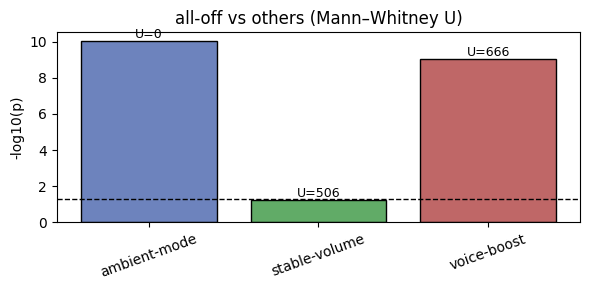

In [1120]:

from scipy.stats import mannwhitneyu

colors = {
    "all-off": "#c56dc8",
    "ambient-mode": "#6d83bd",
    "stable-volume": "#61ab67",
    "voice-boost": "#bf6767"
}
ref = "all-off"
others = [c for c in norm_avg_df.columns if c != ref]

rows = []
a_full = norm_avg_df[ref].dropna().to_numpy()

for c in others:
    b_full = norm_avg_df[c].dropna().to_numpy()
    U, p = mannwhitneyu(a_full, b_full, alternative="two-sided")
    rows.append([c, U, p])

res = pd.DataFrame(rows, columns=["condition", "U_stat", "p_value"])

order = ["ambient-mode", "stable-volume", "voice-boost"]
res = res.set_index("condition").loc[order].reset_index()

labels = res["condition"].to_numpy()
pvals  = res["p_value"].to_numpy()

bar_colors = [colors[label] for label in labels]

plt.figure(figsize=(6, 3))

bars = plt.bar(
    labels,
    -np.log10(np.clip(pvals, 1e-300, 1)),
    color=bar_colors,
    edgecolor="black",
)

# Add U-stat annotations
for i, (u, p) in enumerate(zip(res["U_stat"], res["p_value"])):
    plt.text(i, -np.log10(p) + 0.2, f"U={u:.0f}", ha="center", fontsize=9)

plt.axhline(-np.log10(0.05), linestyle="--", linewidth=1, color="black")

plt.ylabel("-log10(p)")
plt.title("all-off vs others (Mann–Whitney U)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()